## Performance Evaluation LSTMs Moddel on the Test Dataset Before and After Introducing Artificial Missing Data
- **Quantitative Analysis:**
    - Scenarios evaluating 10%, 20%, 40%, and 60% missingness (ensuring at least one missing value per clinical parameter).
- **Qualitative Scenarios (Mechanisms):**
 - MCAR (Missing Completely At Random).
    - Temporal Blocks (to simulate monitor/sensor failure).

### Test Dataset (20%) - 1687 entries
 - Non-Death (0): 1468 (85.4%)
 - Death (1):     246 (14.6%)


## **PART I**

### Missing Values analyses and creation of dataset with Artificial Missing Data

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import (roc_curve, precision_recall_curve, auc, 
                             fbeta_score, confusion_matrix, accuracy_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from scipy import stats 
from scipy.stats import linregress
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


import random
import re
import glob
import os
from pathlib import Path
from typing import List, Dict, Tuple


BASE_DIR = Path().resolve()

In [108]:
print(torch.__version__)

2.9.0


In [43]:

df_test  = pd.read_csv(BASE_DIR / "ds_lstm" / "testLSTM.csv")

In [44]:
# Extra columns in df_test to analyse GCS, Urine and Temp
cols_to_drop = [
        'GCS_count', 'Urine_count', 'Temp_count', 
        'GCS_bin', 'Urine_bin', 'Temp_bin', 'stratify_key'
    ]

In [45]:
features = ['GCS', 'HR', 'Temp', 'Urine', 'DiasABPf', 'MAPf', 'SysABPf']

In [46]:
#df_test.info()

#### Missing data analyses (Golbal and for features)
* **Entries for them start with 3 of 12 values (75% NaN)**
* **The other features start with 6 of 12 valus (50% NaN)**

In [47]:


def na_analysis(df: pd.DataFrame, parameters: list) -> pd.DataFrame:
    """
    Calculates missing value statistics for a list of medical parameters 
    across 12 time steps (t0 to t11) for each instance (RecordID).
    
    Args:
        df (pd.DataFrame): The input dataframe containing 'RecordID' and parameter time-steps.
        parameters (list): A list of strings with the base names of the parameters.
        
    Returns:
        pd.DataFrame: A new dataframe with count and NA percentage statistics per patient.
    """
    
    # 1. Create the new dataset starting with the RecordID column
    na_analyse = pd.DataFrame({'RecordID': df['RecordID']})

    # 2. Iterate over each parameter to calculate valid counts and NA percentages
    for param in parameters:
        # Generate the list of 12 time-step columns for the current parameter (e.g., 'GCS_t0' to 'GCS_t11')
        cols = [f"{param}_t{i}" for i in range(12)]
        
        # n_parameter: Number of valid (non-null) values for this parameter
        na_analyse[f'n_{param}'] = df[cols].count(axis=1)
        
        # na%_parameter: Percentage of missing values (NAs)
        na_analyse[f'na%_{param}'] = (df[cols].isna().sum(axis=1) / 12) * 100

    # 3. Isolate the newly created 'na%' columns to calculate global statistics per patient
    na_cols = [f'na%_{param}' for param in parameters]

    # 4. Calculate mean, standard deviation (std), and median across the parameters (row-wise)
    na_analyse['na%_mean'] = na_analyse[na_cols].mean(axis=1)
    na_analyse['na%_std'] = na_analyse[na_cols].std(axis=1)
    na_analyse['na%_median'] = na_analyse[na_cols].median(axis=1)

    # 5. Calculate the 1st (25%) and 3rd (75%) quartiles
    na_analyse['na%_Q1'] = na_analyse[na_cols].quantile(0.25, axis=1)
    na_analyse['na%_Q3'] = na_analyse[na_cols].quantile(0.75, axis=1)

    return na_analyse

In [48]:

dfna = na_analysis(df=df_test, parameters=features)
dfna.head()

,RecordID,n_GCS,na%_GCS,n_HR,na%_HR,n_Temp,na%_Temp,n_Urine,na%_Urine,n_DiasABPf,na%_DiasABPf,n_MAPf,na%_MAPf,n_SysABPf,na%_SysABPf,na%_mean,na%_std,na%_median,na%_Q1,na%_Q3
0,151444,4,66.666667,9,25.000000,9,25.000000,9,25.000000,9,25.000000,9,25.000000,9,25.000000,30.952381,15.748520,25.000000,25.000000,25.000000
1,135200,5,58.333333,11,8.333333,3,75.000000,10,16.666667,11,8.333333,11,8.333333,11,8.333333,26.190476,28.230439,8.333333,8.333333,37.500000
2,152583,4,66.666667,12,0.000000,4,66.666667,12,0.000000,12,0.000000,12,0.000000,12,0.000000,19.047619,32.530002,0.000000,0.000000,33.333333
3,133565,3,75.000000,10,16.666667,3,75.000000,3,75.000000,10,16.666667,10,16.666667,10,16.666667,41.666667,31.180478,16.666667,16.666667,75.000000
4,153469,3,75.000000,12,0.000000,3,75.000000,5,58.333333,12,0.000000,12,0.000000,12,0.000000,29.761905,37.533054,0.000000,0.000000,66.666667


In [49]:

def geral_na_analysis(df_na_analyse: pd.DataFrame, dataset_name: str, summary_df: pd.DataFrame = None) -> pd.DataFrame:
    """
    Calculates the global mean of 'na%' columns from a given analysis dataframe 
    and appends it as a new row to a summary dataframe, identified by a string.
    
    Args:
        df_na_analyse (pd.DataFrame): The dataframe generated by the `na_analysis` function.
        dataset_name (str): Identifier for the current dataset (e.g., 'raw_data', 'imputed_mean').
        summary_df (pd.DataFrame, optional): The existing summary dataframe. Defaults to None.
        
    Returns:
        pd.DataFrame: The updated summary dataframe containing the new global means row.
    """
    
    # Initialize an empty DataFrame if none is provided
    if summary_df is None:
        summary_df = pd.DataFrame()

    # 1. Identify all columns that contain 'na%' in their name
    na_columns = [col for col in df_na_analyse.columns if 'na%' in col]

    # 2. Define the columns to be excluded 
    # (Included Q1 and Q3 from the previous function just to be safe)
    columns_to_exclude = ['na%_median', 'na%_Q1_Q3_interval', 'na%_Q1', 'na%_Q3']

    # 3. Filter the final list of columns by removing the excluded ones
    target_columns = [col for col in na_columns if col not in columns_to_exclude]

    # 4. Calculate the mean for each of these columns (axis=0 by default)
    global_na_means = df_na_analyse[target_columns].mean()

    # 5. Convert the resulting Series into a single-row DataFrame
    new_row = global_na_means.to_frame().T
    
    # 6. Insert the identifier string at the very beginning of the row
    new_row.insert(0, 'Dataset_ID', dataset_name)

    # 7. Concatenate the new row to the summary dataframe
    if summary_df.empty:
        updated_summary = new_row
    else:
        # ignore_index=True resets the row numbers so they sequence nicely (0, 1, 2...)
        updated_summary = pd.concat([summary_df, new_row], ignore_index=True)

    return updated_summary

In [50]:
# Generiting Global Statistics
statistics_global = pd.DataFrame()
statistics_global = geral_na_analysis(
    df_na_analyse=dfna, 
    dataset_name='Original', 
    summary_df= statistics_global
)


print(statistics_global)

  Dataset_ID   na%_GCS    na%_HR   na%_Temp  na%_Urine  na%_DiasABPf  \
0   Original  60.70863  9.936659  56.393508  26.261876     10.550277   

    na%_MAPf  na%_SysABPf   na%_mean    na%_std  
0  11.104513     10.54038  26.499406  25.669889  


### **Introduction of artificial missing data pipeline**
 - Quantitative:  10%, 20%, 40%, 60%  (at least one missing in each clinica parameter)
 - Qualitative: MCAR and Temporal Blocks

In [51]:
# Help function
def artificial_missing(
    df: pd.DataFrame, 
    feature_prefixes: List[str],
    percent: float, 
    one_at_least: bool = False, 
    mcar: bool = True,
    time_steps: int = 12
) -> pd.DataFrame:
    """
    Introduces artificial missing data into a wide-format clinical dataset.

    Args:
        df: The input pandas DataFrame.
        feature_prefixes: List of feature names to process (e.g., ['GCS', 'Urine']).
        percent: Percentage of CURRENTLY AVAILABLE data to remove per feature (0 to 100).
        one_at_least: If True, guarantees at least 1 value is removed per feature 
            per patient (assuming there was at least 1 valid observation).
        mcar: If True, applies Missing Completely At Random. If False, simulates 
            a temporal block (e.g., monitor failure), removing consecutive/closest values.
        time_steps: Number of sequential time columns (default is 12, for t0 to t11).

    Returns:
        A copy of the DataFrame with artificially injected missing values.
    """
    
    df_out = df.copy()
    
    for prefix in feature_prefixes:
        # Define the chronological columns for the current feature
        cols = [f'{prefix}_t{i}' for i in range(time_steps)]
        
        def inject_missing_row(row: pd.Series) -> pd.Series:
            # Extract just the current feature's timeline for this specific patient
            vals = row[cols].copy()
            
            # Identify which time steps actually contain data
            valid_idx = vals.dropna().index.tolist()
            n_valid = len(valid_idx)
            
            # If the patient has no data for this feature, there's nothing to remove
            #if n_valid == 0:
            #    return vals
            
            # Calculate how many to remove. (round for up)
            n_remove = int((n_valid * (percent / 100.0)) + 0.5)
            
            if one_at_least:
                n_remove = max(1, n_remove)
                
            n_remove = min(n_remove, n_valid)
            
            # if n_remove == 0:
            #     return vals
                
            if mcar:
                # Select values purely randomly across the timeline
                to_remove = random.sample(valid_idx, n_remove)
                
            else:
                # Type: Temporal Block (Monitor Failure)
                # Pick a random failure start point from the available data
                start_col = random.choice(valid_idx)
                start_time = int(start_col.split('_t')[-1])
                
                # Sort available columns based on proximity to the failure point.
                # We prioritize the start point, then forward-in-time values, 
                
                def temporal_distance(col_name: str):
                    t = int(col_name.split('_t')[-1])
                    dist = abs(t - start_time)
                    # Tuple: (absolute distance, is_past)
                    # is_past=False (future) comes before is_past=True (past) in sorting
                    return (dist, t < start_time)
                
                valid_sorted = sorted(valid_idx, key=temporal_distance)
                to_remove = valid_sorted[:n_remove]
                
            # Apply the NAs to the selected temporal slots
            vals[to_remove] = np.nan
            return vals

        # Apply the row logic to the dataframe
        df_out[cols] = df_out.apply(inject_missing_row, axis=1)
        
    return df_out



In [52]:


all_df_test = {}
all_df_test["0%"] = df_test # dicts to store new df (with all scenarios of missing datas)

all_df_nas ={}
all_df_nas["0%"] = dfna # #dicts to store the analysis of each one



In [53]:

#main loop to create all scenarios 

missing_percentages = [10, 20, 40, 60]
mcar_options = [True, False]

for is_mcar in mcar_options:
    for percent in missing_percentages:
        # Set the name prefix based on the MCAR status
        missing_type_name = "MCAR" if is_mcar else "Temporal"
        
        # dataset name 
        dataset_name = f"{missing_type_name}{percent}"
        
        # dictionary key ( 0%, 10% MCAR, 40% Temporal...)
        dict_key = f"{percent}% {missing_type_name}"
        
        # 1. Generate artificial missing data
        temp_df = artificial_missing(
            df_test, 
            features, 
            percent=percent, 
            one_at_least=True, 
            mcar=is_mcar
        )
        
        # 2. Perform NA (Missing Data) analysis
        temp_na_analysis = na_analysis(df=temp_df, parameters=features)
        
        # 3. Update global statistics
        statistics_global = geral_na_analysis(
            df_na_analyse=temp_na_analysis, 
            dataset_name=dataset_name, 
            summary_df=statistics_global
        )
        
        # 4. Save results to the global dictionaries
        all_df_nas[dict_key] = temp_na_analysis
        all_df_test[dict_key] = temp_df

In [54]:
#print(all_df_test.keys())

In [55]:
#print(all_df_nas.keys())

In [56]:
statistics_global.head()

,Dataset_ID,na%_GCS,na%_HR,na%_Temp,na%_Urine,na%_DiasABPf,na%_MAPf,na%_SysABPf,na%_mean,na%_std
0,Original,60.708630,9.936659,56.393508,26.261876,10.550277,11.104513,10.540380,26.499406,25.669889
1,MCAR10,69.041964,18.269992,64.726841,34.595210,18.883610,19.437846,18.873713,34.832740,25.669889
2,MCAR20,70.135590,26.400435,66.468725,40.761085,26.994260,27.528702,26.984363,40.753308,22.079848
3,MCAR40,76.583531,45.764054,73.837094,55.675970,46.095606,46.461797,46.095606,55.787665,15.619331
4,MCAR60,84.125099,64.172605,82.556413,70.585907,64.454671,64.642716,64.444774,70.711741,10.224077


### Handle with NAs - Same way that training data
- **Forward Fill (FFILL) Horizontally: Within each patient's timeline (row), missing values are replaced by the last known valid observation.** - **We assume that the most recent state is the best predictor of the current state.**
- **Row Mean Imputation: If the first observation of a timeline is missing (where forward fill cannot reach),** - **It is filled with the arithmetic mean of all available measurements for that specific patient.**

In [57]:

def impute_missing_values(
    df: pd.DataFrame, 
    feature_prefixes: List[str], 
    time_steps: int = 12
) -> pd.DataFrame:
    """Imputes missing values horizontally in a wide-format clinical dataset.

    Applies a Forward Fill (LOCF) across time columns for each feature, 
    assuming that the most recent state is the best predictor of the 
    current state. If initial observations are missing, they are filled 
    with the arithmetic mean of all available measurements for that patient.

    Args:
        df: The input pandas DataFrame containing the clinical data.
        feature_prefixes: A list of string prefixes for the features 
            to be imputed (e.g., ['GCS', 'Urine', 'Temp']).
        time_steps: The total number of sequential time columns per feature.
            Defaults to 12 (representing t0 to t11).

    Returns:
        A new pandas DataFrame with the imputed values.
    """
    # Create a copy to prevent SettingWithCopy warnings and mutating original data
    df_imputed = df.copy()
    
    for prefix in feature_prefixes:
        # Generate the chronological column names for the current feature
        # Example: ['GCS_t0', 'GCS_t1', ..., 'GCS_t11']
        cols = [f'{prefix}_t{i}' for i in range(time_steps)]
        
        # 1. Forward Fill (FFILL) horizontally
        # Fills missing values with the last known valid observation (axis=1)
        df_imputed[cols] = df_imputed[cols].ffill(axis=1)
        
        # 2. Row Mean Imputation for remaining initial NaNs
        # Calculates the mean of the available measurements for this specific row (patient)
        row_means = df_imputed[cols].mean(axis=1)
        
        # Fills the remaining NaNs using the calculated row means. 
        # Iterating over columns is the safest and most efficient way to map a Series to a DataFrame.
        for col in cols:
            df_imputed[col] = df_imputed[col].fillna(row_means)
            
    return df_imputed



In [58]:
features = ['GCS', 'Urine', 'Temp', 'HR', 'DiasABPf', 'MAPf', 'SysABPf']


In [59]:
for nome, df in all_df_test.items():
    all_df_test[nome] = impute_missing_values(df, feature_prefixes=features)


## PART II - Predictions and Perfomance Analysis  

In [60]:

# Detect CUDA or MPS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Mac (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU NVIDIA (CUDA)")
else:
    device = torch.device("cpu")
    print("Only CPU")

Mac (MPS)


#### Extracting normalization parameters from the training set to apply to the test set

In [61]:
df_train = pd.read_csv(BASE_DIR / "ds_lstm" / "trainLSTM.csv")


In [62]:
X = df_train.drop(['RecordID', 'In-hospital_death'], axis=1)
y = df_train['In-hospital_death'].values

# Normalizaton
scaler = StandardScaler()
scaler.fit(X) 

n_timesteps = 12
n_features = X.shape[1] // n_timesteps


In [63]:

# This function applies the necessary transformations to prepare data for a PyTorch 
# LSTM model, including dropping specific columns, scaling features using the 
# provided StandardScaler, reshaping for sequences, and converting to PyTorch tensors.


def preprocess_with_fitted_scaler(
    dfs: Dict[str, pd.DataFrame], scaler: StandardScaler
) -> Dict[str, Dict[str, torch.Tensor]]:
    """Preprocesses a dictionary of DataFrames using a pre-fitted scaler.
    
    Args:
        dfs: A dictionary where keys are string identifiers (e.g., 'test_set_1') 
            and values are pandas DataFrames containing the patient data.
        scaler: A scikit-learn StandardScaler instance that has already been fitted
            on the training data.

    Returns:
        A dictionary with the same keys as the input. The values are dictionaries
        containing two PyTorch tensors:
            - 'X': The preprocessed feature tensor with shape (samples, time_steps, features).
            - 'y': The target tensor with shape (samples, 1).
    """
    processed_data = {}

    cols_to_drop = [
        'GCS_count', 'Urine_count', 'Temp_count', 
        'GCS_bin', 'Urine_bin', 'Temp_bin', 'stratify_key',
        'RecordID', 'In-hospital_death'
    ]

    for name, df in dfs.items():
        #  Feature Selection
        X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
        
        
        if 'In-hospital_death' in df.columns:
             y = df['In-hospital_death'].values
        else:
             # Handle cases where testing data might not have labels 
             y = None 

        #  Normalization (Crucial: use .transform(), NOT .fit_transform())
        X_scaled = scaler.transform(X)

        #  Reshape (Samples, Time_Steps, Features)
        n_samples = X_scaled.shape[0]
        n_timesteps = 12
        n_features = X_scaled.shape[1] // n_timesteps

        X_reshaped = X_scaled.reshape(n_samples, n_timesteps, n_features)

        # 4. Tensorizing for PyTorch
        X_tensor = torch.tensor(X_reshaped, dtype=torch.float32)
        
        if y is not None:
             y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        else:
             y_tensor = None

        processed_data[name] = {
            'X': X_tensor,
            'y': y_tensor
        }
        
    return processed_data




In [64]:
processed_test_data = preprocess_with_fitted_scaler(all_df_test, scaler)



In [65]:
print(processed_test_data["0%"].keys())

dict_keys(['X', 'y'])


In [66]:
X_test_tensor = processed_test_data["0%"]['X']#

y_test_tensor = processed_test_data["0%"]['y']

#print(X_test_tensor)

In [67]:
# THE IMPLEMTENTION PERMIT TO USE VARIATIONAL ESTIMATOR MODELS 
# BUT IT WAS DECIDED TO NOT EVALUATE OTHER BAYESIAN MODELS THAT NOT MCDROPOOUT BECAUSE THE PERFORMANCE IN TRAIN SET


from blitz.modules import BayesianLSTM, BayesianLinear
from blitz.utils import variational_estimator

@variational_estimator
class LSTMClassifier(nn.Module):
    """Implementation of an LSTM for binary classification (Deterministic or Bayesian).

    This module allows toggling between a standard deterministic LSTM and a 
    Bayesian LSTM using Variational Inference (via the BLITZ library).

    Attributes:
        hidden_dim (int): Number of features in the hidden state.
        layer_dim (int): Number of recurrent layers (stacked LSTMs).
        bayesian (bool): Flag indicating if the network uses Bayesian layers.
        dropout_rate (float): The dropout probability.
        lstm (nn.LSTM): The deterministic LSTM module (if bayesian is False).
        lstm_layers (nn.ModuleList): Stacked Bayesian LSTM layers (if bayesian is True).
        fc (nn.Module): The fully connected linear layer (Deterministic or Bayesian).
        dropout_layer (nn.Dropout): Post-LSTM dropout layer.
        sigmoid (nn.Sigmoid): Sigmoid activation for binary classification.
    """

    def __init__(self, input_dim: int, hidden_dim: int, layer_dim: int, 
                 output_dim: int, dropout: float = 0.2, bayesian: bool = False):
        """Initializes the LSTMClassifier.

        Args:
            input_dim: Number of expected features in the input sequence.
            hidden_dim: Number of features in the hidden state 'h'.
            layer_dim: Number of recurrent layers (stacked LSTMs).
            output_dim: Number of output units (typically 1 for binary classification).
            dropout: Dropout probability in [0, 1]. Defaults to 0.2.
            bayesian: If True, uses Bayesian layers with Variational Inference. 
                Defaults to False.

        Raises:
            ValueError: If the dropout probability is not between 0.0 and 1.0.
        """
        super(LSTMClassifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.bayesian = bayesian
        
        # --- Dropout validation ---
        if dropout is not None and not (0.0 <= dropout <= 1.0):
            raise ValueError(f"Dropout must be in [0, 1] or None, got {dropout}")
        self.dropout_rate = dropout
        
        # --- Architecture definition ---
        if self.bayesian:
            # BLITZ BayesianLSTM does not support 'num_layers' natively.
            # We stack them manually using nn.ModuleList.
            self.lstm_layers = nn.ModuleList()
            for i in range(layer_dim):
                eff_input_dim = input_dim if i == 0 else hidden_dim
                self.lstm_layers.append(BayesianLSTM(eff_input_dim, hidden_dim))
            
            # Bayesian Fully Connected Layer
            self.fc = BayesianLinear(hidden_dim, output_dim)
        else:
            # Original Deterministic Configuration
            lstm_dropout = dropout if (dropout is not None and layer_dim > 1) else 0.0
            self.lstm = nn.LSTM(
                input_size=input_dim, 
                hidden_size=hidden_dim, 
                num_layers=layer_dim,
                batch_first=True,
                dropout=lstm_dropout
            )
            self.fc = nn.Linear(hidden_dim, output_dim)

        # --- Post-LSTM & Inter-layer Dropout ---
        self.dropout_layer = nn.Dropout(dropout) if dropout is not None else None
        
        # Sigmoid: P(y=1|X)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Defines the forward pass of the model.

        Args:
            x: Input tensor of shape (batch_size, sequence_length, input_dim).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim) containing 
                probabilities bounded between 0 and 1.
        """
        if self.bayesian:
            # Pass through stacked Bayesian layers
            out = x
            for i, lstm_layer in enumerate(self.lstm_layers):
                out, _ = lstm_layer(out)
                # Apply inter-layer dropout for stacked layers (except the last one)
                if self.dropout_layer is not None and i < (self.layer_dim - 1):
                    out = self.dropout_layer(out)
            
            # Many-to-One: extract the hidden state of the last timestep
            last_out = out[:, -1, :]
        else:
            # Deterministic pass (PyTorch handles zero-initialization of h0/c0 internally)
            out, _ = self.lstm(x)
            last_out = out[:, -1, :]

        # Apply post-LSTM dropout before the fully connected layer
        if self.dropout_layer is not None:
            last_out = self.dropout_layer(last_out)

        # Final classification
        return self.sigmoid(self.fc(last_out))

    def __repr__(self) -> str:
        """Returns a string representation of the model."""
        dropout_info = f"{self.dropout_rate}" if self.dropout_rate is not None else "disabled"
        return (f"LSTMClassifier(hidden={self.hidden_dim}, layers={self.layer_dim}, "
                f"dropout={dropout_info}, bayesian={self.bayesian})")

In [68]:
# LOAD all trained Models

dir_models2 = BASE_DIR / "models2"

base_params = {
    'input_dim': n_features,
    'hidden_dim': 128,
    'layer_dim': 2,
    'output_dim': 1,
    'dropout': 0.2,
    'bayesian': False,
}

def load_single_model(path):
    model = LSTMClassifier(**base_params)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

loaded_models = {}

# Standard models: one per fold -> loaded_models["standard1"] ... loaded_models["standard15"]
for fold in range(1, 16):
    path = os.path.join(dir_models2, f"standard_L2_D0.2_fold{fold}.pth")
    loaded_models[f"standard{fold}"] = load_single_model(path)

# Ensemble models: 5 members per fold, stored as a list
# -> loaded_models["ensemble1"] ... loaded_models["ensemble15"], where loaded_models["ensemble1"][0,...,5]

for fold in range(1, 16):
    members = []
    for ens_idx in range(1, 6):
        path = os.path.join(dir_models2, f"Ensemb_L2_D0.2_fold{fold}_ens{ens_idx}.pth")
        members.append(load_single_model(path))
    loaded_models[f"ensemble{fold}"] = members

In [69]:
len(loaded_models)

30

In [70]:
def enable_mc_dropout(model: nn.Module):
    """Forces standard and LSTM dropout layers to remain active during eval mode."""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout') or isinstance(m, nn.LSTM):
            m.train()

In [71]:

# =========================================================================
# IMBALANCE-AWARE CALIBRATION METRICS  (test set is ~14.5% / 85.5%)
# =========================================================================
def _balanced_brier_score(y_true, y_prob):
    """
    Class-balanced Brier score: average of the per-class mean squared error so
    each class contributes equally regardless of prevalence. On a 14.5/85.5 split
    the standard Brier is dominated by the majority class; this corrects for that.
    """
    y_true = np.asarray(y_true, float); y_prob = np.asarray(y_prob, float)
    pos, neg = (y_true == 1), (y_true == 0)
    b_pos = np.mean((y_prob[pos] - 1.0) ** 2) if pos.any() else 0.0
    b_neg = np.mean((y_prob[neg] - 0.0) ** 2) if neg.any() else 0.0
    return 0.5 * (b_pos + b_neg)


def _expected_calibration_error(y_true, y_prob, n_bins=10, strategy='quantile'):
    """
    Proper population-weighted ECE: ECE = sum_b (n_b / N) * |acc_b - conf_b|.
    Uses quantile bins by default so that, with predictions clustered near the
    low base rate, every bin holds a comparable number of samples (uniform bins
    leave most upper bins empty on imbalanced data).
    """
    y_true = np.asarray(y_true, float); y_prob = np.asarray(y_prob, float)
    N = len(y_true)
    if strategy == 'quantile':
        edges = np.unique(np.quantile(y_prob, np.linspace(0, 1, n_bins + 1)))
    else:
        edges = np.linspace(0, 1, n_bins + 1)
    if len(edges) < 2:
        return 0.0
    bin_ids = np.clip(np.digitize(y_prob, edges, right=True), 1, len(edges) - 1)
    ece = 0.0
    for b in range(1, len(edges)):
        mask = bin_ids == b
        nb = mask.sum()
        if nb == 0:
            continue
        ece += (nb / N) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece




In [72]:
def evaluate_in_dataset(model, df_subset, use_mcdropout: bool, model_type: str, ID: str,
                        mc_samples: int = 50, threshold: float = 0.0):
    """
    Evaluates a model configuration on a specific dataset split.
    Computes discrimination (AUCs, accuracy) and imbalance-aware calibration
    metrics (standard + balanced Brier, weighted ECE, calibration slope).
    Uses the optimal Balanced-Accuracy threshold by default, or a custom one.
    Returns (metrics_row, uncertainty_list, fig, per_instance_preds); the figure
    is closed instead of shown to avoid inline rendering.
    """
    X_tensor = df_subset['X'].to(device)

    if 'y' in df_subset:
        y_true = df_subset['y'].cpu().numpy() if torch.is_tensor(df_subset['y']) else df_subset['y']
    else:
        raise ValueError("Error: Could not find key 'y' in data subset.")

    y_true = np.array(y_true).flatten()
    original_indices = np.arange(len(y_true))

    if model_type == 'ensemble':
        for member in model:
            member.eval()
    else:
        model.eval()

    # ---------------------------------------------------------------------
    # PREDICTION (Bayesian path removed)
    # per_instance_preds: one entry per instance ->
    #   standard          -> scalar probability
    #   MC dropout        -> list of mc_samples probabilities
    #   ensemble          -> list of member probabilities
    # ---------------------------------------------------------------------
    with torch.no_grad():
        if use_mcdropout:
            enable_mc_dropout(model)
            mc_preds = [model(X_tensor) for _ in range(mc_samples)]
            mc_preds_stack = torch.stack(mc_preds)                       # [S, N, 1]
            y_pred_prob = mc_preds_stack.mean(dim=0).cpu().numpy()
            uncertainty_var = mc_preds_stack.var(dim=0).cpu().numpy()
            samples = mc_preds_stack.cpu().numpy().reshape(mc_preds_stack.shape[0], -1)  # [S, N]
            per_instance_preds = [list(map(float, col)) for col in samples.T]            # N lists

        elif model_type == 'ensemble':
            ens_preds = [member(X_tensor) for member in model]
            ens_preds_stack = torch.stack(ens_preds)                     # [M, N, 1]
            y_pred_prob = ens_preds_stack.mean(dim=0).cpu().numpy()
            uncertainty_var = ens_preds_stack.var(dim=0).cpu().numpy()
            votes_class_1 = (ens_preds_stack > 0.5).sum(dim=0).cpu().numpy()
            samples = ens_preds_stack.cpu().numpy().reshape(ens_preds_stack.shape[0], -1)  # [M, N]
            per_instance_preds = [list(map(float, col)) for col in samples.T]              # N lists

        else:  # standard
            y_pred_prob = model(X_tensor).cpu().numpy()
            uncertainty_var = np.zeros_like(y_pred_prob)
            per_instance_preds = [float(v) for v in np.array(y_pred_prob).flatten()]       # N scalars

    y_pred_prob = np.array(y_pred_prob).flatten()
    uncertainty_var = np.array(uncertainty_var).flatten()
    if model_type == 'ensemble':
        votes_class_1 = np.array(votes_class_1).flatten()

    fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_pred_prob)
    pr_auc = auc(recall_curve, precision_curve)

    # Optimal threshold via Balanced Accuracy
    balanced_accuracies = (tpr + (1 - fpr)) / 2
    best_idx = np.argmax(balanced_accuracies)

    # ---------------------------------------------------------------------
    # THRESHOLD LOGIC
    # ---------------------------------------------------------------------
    applied_threshold = threshold if threshold != 0.0 else thresholds_roc[best_idx]

    # Confusion matrix at the applied threshold
    y_pred_discrete = (y_pred_prob >= applied_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_discrete).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    applied_bal_acc = (recall + specificity) / 2

    # =====================================================================
    # CALIBRATION METRICS (imbalance-corrected)
    # =====================================================================
    brier_score = brier_score_loss(y_true, y_pred_prob)                 # standard (prevalence-sensitive)
    brier_balanced = _balanced_brier_score(y_true, y_pred_prob)         # class-balanced
    ece = _expected_calibration_error(y_true, y_pred_prob, n_bins=10, strategy='quantile')  # weighted

    # Calibration slope (logistic regression of labels on predicted log-odds)
    clipped_preds = np.clip(y_pred_prob, 1e-6, 1 - 1e-6)
    logits = np.log(clipped_preds / (1 - clipped_preds))
    slope, _, _, _, _ = linregress(logits, y_true)

    # Uncertainty extraction
    wrong_indices = np.where(y_true != y_pred_discrete)[0]
    uncertainty_list = []
    for idx in range(len(y_true)):
        is_wrong = idx in wrong_indices
        row_data = {
            'original_index': int(original_indices[idx]),
            'true_label': float(y_true[idx]),
            'pred_prob': float(y_pred_prob[idx]),
            'pred_discrete': int(y_pred_discrete[idx]),
            'is_wrong': is_wrong
        }
        save_row = False
        if is_wrong:
            save_row = True
        if use_mcdropout and uncertainty_var[idx] > 0.05:
            save_row = True
            row_data['variance'] = float(uncertainty_var[idx])
            row_data['std_dev'] = float(np.sqrt(uncertainty_var[idx]))
        if model_type == 'ensemble':
            row_data['ensemble_votes_1'] = int(votes_class_1[idx])
            if votes_class_1[idx] in [2, 3]:
                save_row = True
        if save_row:
            uncertainty_list.append(row_data)

    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Evaluation: {ID} (Applied Thr: {applied_threshold:.3f})', fontweight='bold')

    axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[0].scatter((1 - specificity), recall, color='red', marker='x', zorder=5, s=100, label='Applied Thr. Pt.')
    axes[0].set_title('ROC Curve'); axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(loc="lower right")

    axes[1].plot(recall_curve, precision_curve, color='green', lw=2, label=f'AUC = {pr_auc:.3f}')
    axes[1].scatter(recall, precision, color='red', marker='x', zorder=5, s=100, label='Applied Thr. Pt.')
    axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].legend(loc="lower left")

    cm_matrix = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[2])
    axes[2].set_title(f'Confusion Matrix\n(Bal Acc: {applied_bal_acc:.3f} | Brier: {brier_score:.3f} '
                      f'| Brier_bal: {brier_balanced:.3f} | ECE: {ece:.3f})')
    axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
    axes[2].set_xticklabels(['0', '1']); axes[2].set_yticklabels(['0', '1'])

    plt.tight_layout(); plt.close(fig)

    metrics_row = {
        'Model_ds': ID,
        'AUC-ROC': roc_auc,
        'AUC-PR': pr_auc,
        'Applied_Threshold': applied_threshold,
        'Balanced_Accuracy': applied_bal_acc,
        'Brier_Score': brier_score,            # standard
        'Brier_Score_Bal': brier_balanced,     # class-balanced (imbalance-corrected)
        'ECE': ece,                            # population-weighted, quantile bins
        'Calibration_Slope': slope,
        'Accuracy': accuracy,
        'Recall (Sens)': recall,
        'Precision (PPV)': precision,
        'Specificity': specificity,
        'NPV': npv,
        'True_Positives': tp, 'False_Positives': fp,
        'True_Negatives': tn, 'False_Negatives': fn
    }

    return metrics_row, uncertainty_list, fig, per_instance_preds




In [73]:
def evaluate(model_name: str, model, model_type: str, processed_test_data: dict,
             mc_samples: int = 50, threshold: float = 0.0):
    global models_metrics_df
    global rows_uncertainty_dict
    global saved_plots_dict
    global df_pat                      # patient-level predictions (one row per test instance)

    print(f"\n{'='*60}")
    print(f"Starting Evaluation for Model: {model_name.upper()} ({model_type})")
    print(f"{'='*60}")

    pat_parts = []   # this model's per-instance predictions, across all datasets

    for dataset_name, df_subset in processed_test_data.items():
        # --- PATH A: base evaluation (standard or ensemble) ---
        ID_base = f"{model_name}/{dataset_name}"
        metrics_row, uncertainty_list, fig_base, preds_base = evaluate_in_dataset(
            model=model, df_subset=df_subset, use_mcdropout=False,
            model_type=model_type, ID=ID_base, mc_samples=mc_samples, threshold=threshold
        )
        models_metrics_df = pd.concat([models_metrics_df, pd.DataFrame([metrics_row])], ignore_index=True)
        rows_uncertainty_dict[ID_base] = uncertainty_list
        saved_plots_dict[ID_base] = fig_base

        # row keys for df_pat, in test-dataset order
        y_true = (df_subset['y'].cpu().numpy() if torch.is_tensor(df_subset['y'])
                  else np.array(df_subset['y'])).flatten()
        part = pd.DataFrame({'Dataset': dataset_name, 'instance': np.arange(len(y_true)), 'y_true': y_true})
        part[model_name] = pd.Series(preds_base, dtype=object)      # scalar (standard) / list (ensemble)

        # --- PATH B: MC Dropout (standard models only) ---
        if model_type == 'standard':
            ID_mc = f"{model_name}_mcdropout/{dataset_name}"
            metrics_row_mc, uncertainty_list_mc, fig_mc, preds_mc = evaluate_in_dataset(
                model=model, df_subset=df_subset, use_mcdropout=True,
                model_type=model_type, ID=ID_mc, mc_samples=mc_samples, threshold=threshold
            )
            models_metrics_df = pd.concat([models_metrics_df, pd.DataFrame([metrics_row_mc])], ignore_index=True)
            rows_uncertainty_dict[ID_mc] = uncertainty_list_mc
            saved_plots_dict[ID_mc] = fig_mc
            part[f'{model_name}_mcdropout'] = pd.Series(preds_mc, dtype=object)   # list of preds

        pat_parts.append(part)

    # merge this model's column(s) into the global patient-level df, aligned by (Dataset, instance)
    chunk = pd.concat(pat_parts, ignore_index=True)
    if len(df_pat) == 0:
        df_pat = chunk
    else:
        df_pat = df_pat.merge(chunk.drop(columns=['y_true']), on=['Dataset', 'instance'], how='outer')

In [74]:
models_metrics_df = pd.DataFrame()
saved_plots_dict = {}
rows_uncertainty_dict = {}       # Key:{model_name}/{dataset_name} :  Value: "problematic" rows (for qualitative analyse)
df_pat = pd.DataFrame()          # patient: all predictions

for model_name, model_obj in loaded_models.items():
    m_type = 'ensemble' if 'ensemble' in model_name else 'standard'   
    evaluate(
        model_name=model_name,
        model=model_obj,
        model_type=m_type,
        processed_test_data=processed_test_data,
        mc_samples=50,
        threshold=0.0
    )


Starting Evaluation for Model: STANDARD1 (standard)

Starting Evaluation for Model: STANDARD2 (standard)

Starting Evaluation for Model: STANDARD3 (standard)

Starting Evaluation for Model: STANDARD4 (standard)

Starting Evaluation for Model: STANDARD5 (standard)

Starting Evaluation for Model: STANDARD6 (standard)

Starting Evaluation for Model: STANDARD7 (standard)

Starting Evaluation for Model: STANDARD8 (standard)

Starting Evaluation for Model: STANDARD9 (standard)

Starting Evaluation for Model: STANDARD10 (standard)

Starting Evaluation for Model: STANDARD11 (standard)

Starting Evaluation for Model: STANDARD12 (standard)

Starting Evaluation for Model: STANDARD13 (standard)

Starting Evaluation for Model: STANDARD14 (standard)

Starting Evaluation for Model: STANDARD15 (standard)

Starting Evaluation for Model: ENSEMBLE1 (ensemble)

Starting Evaluation for Model: ENSEMBLE2 (ensemble)

Starting Evaluation for Model: ENSEMBLE3 (ensemble)

Starting Evaluation for Model: ENSEMBLE

In [75]:
print(saved_plots_dict.keys())

dict_keys(['standard1/0%', 'standard1_mcdropout/0%', 'standard1/10% MCAR', 'standard1_mcdropout/10% MCAR', 'standard1/20% MCAR', 'standard1_mcdropout/20% MCAR', 'standard1/40% MCAR', 'standard1_mcdropout/40% MCAR', 'standard1/60% MCAR', 'standard1_mcdropout/60% MCAR', 'standard1/10% Temporal', 'standard1_mcdropout/10% Temporal', 'standard1/20% Temporal', 'standard1_mcdropout/20% Temporal', 'standard1/40% Temporal', 'standard1_mcdropout/40% Temporal', 'standard1/60% Temporal', 'standard1_mcdropout/60% Temporal', 'standard2/0%', 'standard2_mcdropout/0%', 'standard2/10% MCAR', 'standard2_mcdropout/10% MCAR', 'standard2/20% MCAR', 'standard2_mcdropout/20% MCAR', 'standard2/40% MCAR', 'standard2_mcdropout/40% MCAR', 'standard2/60% MCAR', 'standard2_mcdropout/60% MCAR', 'standard2/10% Temporal', 'standard2_mcdropout/10% Temporal', 'standard2/20% Temporal', 'standard2_mcdropout/20% Temporal', 'standard2/40% Temporal', 'standard2_mcdropout/40% Temporal', 'standard2/60% Temporal', 'standard2_mc

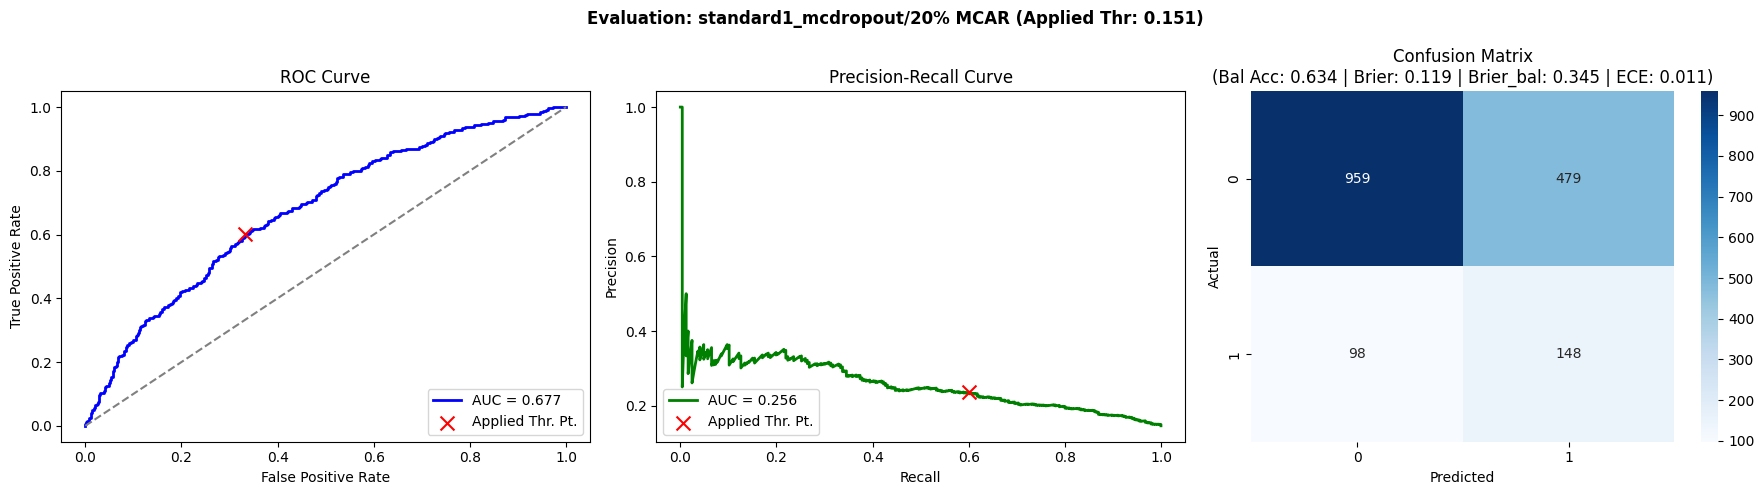

In [76]:
# Visualize any model perfomance in a chosen scenario, chage target_id for any dict_keys 
target_id = "standard1_mcdropout/20% MCAR"
display(saved_plots_dict[target_id])


In [77]:
models_metrics_df

,Model_ds,AUC-ROC,AUC-PR,Applied_Threshold,Balanced_Accuracy,Brier_Score,Brier_Score_Bal,ECE,Calibration_Slope,Accuracy,Recall (Sens),Precision (PPV),Specificity,NPV,True_Positives,False_Positives,True_Negatives,False_Negatives
0,standard1/0%,0.675594,0.258998,0.116794,0.634763,0.118374,0.346412,0.015851,0.135644,0.554632,0.747967,0.211009,0.521558,0.923645,184,688,750,62
1,standard1_mcdropout/0%,0.675068,0.258425,0.117490,0.636501,0.118388,0.346084,0.017648,0.136474,0.557601,0.747967,0.212226,0.525035,0.924113,184,683,755,62
2,standard1/10% MCAR,0.677038,0.259236,0.147662,0.636001,0.118295,0.344877,0.015132,0.136015,0.660333,0.601626,0.237942,0.670376,0.907721,148,474,964,98
3,standard1_mcdropout/10% MCAR,0.677417,0.259462,0.148204,0.635305,0.118290,0.344475,0.015447,0.137130,0.659145,0.601626,0.237179,0.668985,0.907547,148,476,962,98
4,standard1/20% MCAR,0.676264,0.256333,0.132322,0.632066,0.118545,0.345441,0.015526,0.133203,0.610451,0.662602,0.221467,0.601530,0.912447,163,573,865,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,ensemble15/60% MCAR,0.654358,0.228554,0.151688,0.628159,0.121253,0.338540,0.030748,0.133889,0.580760,0.695122,0.213217,0.561196,0.914966,171,631,807,75
401,ensemble15/10% Temporal,0.683382,0.253014,0.159188,0.655014,0.118898,0.337549,0.030631,0.166008,0.649644,0.662602,0.243284,0.647427,0.918146,163,507,931,83
402,ensemble15/20% Temporal,0.682059,0.254940,0.157149,0.651430,0.118646,0.336711,0.027463,0.167688,0.637767,0.670732,0.237752,0.632128,0.918182,165,529,909,81
403,ensemble15/40% Temporal,0.682438,0.272308,0.174459,0.649615,0.118319,0.332018,0.022960,0.168871,0.686461,0.597561,0.255208,0.701669,0.910650,147,429,1009,99


In [78]:
models_metrics_df.to_csv(BASE_DIR / "models_metrics.csv")

In [79]:
# helpers fo statistical hipoteses test

CATEGORY_ORDER = ['standard', 'standard (mcDropout)', 'ensemble']
PALETTE = {'standard': '#4C72B0', 'standard (mcDropout)': '#55A868', 'ensemble': '#C44E52'}
SHORT   = {'standard': 'std', 'standard (mcDropout)': 'mcD', 'ensemble': 'ens'}
SCENARIOS = ['0%', '10% MCAR', '20% MCAR', '40% MCAR', '60% MCAR',
             '10% Temporal', '20% Temporal', '40% Temporal', '60% Temporal']


# ----------------------------- helpers ----------------------------------
def _categorize(name):
    n = name.lower()
    if 'mcdropout' in n:         return 'standard (mcDropout)'
    if n.startswith('ensemble'): return 'ensemble'
    if n.startswith('standard'): return 'standard'
    return None

def _scenario_meta(s):
    if s == '0%': return 0, '0%'
    return int(s.split('%')[0]), ('MCAR' if 'MCAR' in s else 'Temporal')

def _ci95(v):
    n = len(v)
    return stats.t.ppf(0.975, n-1) * (v.std(ddof=1)/np.sqrt(n)) if n > 1 else 0.0

def _rm_anova(Y):
    """One-way repeated-measures (paired) ANOVA. Y: (n_folds, k_conditions), no NaNs."""
    n, k = Y.shape
    grand, cm, sm = Y.mean(), Y.mean(0), Y.mean(1)
    ss_cond = n * ((cm - grand)**2).sum()
    ss_err  = ((Y - grand)**2).sum() - ss_cond - k*((sm - grand)**2).sum()
    df_c, df_e = k-1, (k-1)*(n-1)
    if ss_err <= 0 or df_e <= 0: return np.nan, np.nan
    F = (ss_cond/df_c) / (ss_err/df_e)
    return F, stats.f.sf(F, df_c, df_e)

def _holm(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for r, idx in enumerate(order):
        run = max(run, (m-r)*p[idx]); adj[idx] = min(run, 1.0)
    return adj

def _prep(df):
    d = df.copy()
    d[['Model', 'Dataset']] = d['Model_ds'].str.split('/', n=1, expand=True)
    d['Category'] = d['Model'].map(_categorize)
    d['Fold'] = d['Model'].str.extract(r'(\d+)').astype(float)
    return d[d['Category'].notna()]




### Barplot with erros

In [80]:


AUCPR_YLIM        = (0.200, 0.290)
AUCPR_MAJOR_STEP  = 0.010   # solid gridline + labeled tick every 0.010
AUCPR_MINOR_STEP  = 0.005   # dashed gridline halfway between major ticks

def _is_aucpr(metric_col):
    key = metric_col.lower().replace('-', '').replace('_', '').replace(' ', '')
    return 'aucpr' in key

def plot_bar_metrics(models_metrics_df, metric_col, zoom_value_axis=True):
    """
    Plots a dynamically structured grid of scenarios:
    - Row 1: 1 Centralized 0% chart (spans middle cols) with stats on the left.
    - Other rows: 2 charts per row (Same NA% missingness: MCAR on left, Temporal on right).
      Stats are marginal (Far Left for MCAR, Far Right for Temporal).
    - Post-hocs include both Paired t-tests + Holm (for ANOVA) and Wilcoxon + Holm (for Friedman).
    """
    df = _prep(models_metrics_df)
    
    # 1. Identify and group scenarios systematically
    scenario_0 = None
    for s in SCENARIOS:
        if '0%' in s or 'baseline' in s.lower():
            scenario_0 = s
            break
    if not scenario_0 and len(SCENARIOS) > 0:
        scenario_0 = SCENARIOS[0]

    # Extract unique NA percentages for subsequent lines
    percentages = []
    for s in SCENARIOS:
        if s == scenario_0:
            continue
        match = re.search(r'(\d+%)', s)
        if match:
            pct = match.group(1)
            if pct not in percentages and pct != '0%':
                percentages.append(pct)
                
    # Pair MCAR and Temporal scenarios per NA% level
    rows_scenarios = []
    for pct in percentages:
        mcar_s = None
        temp_s = None
        for s in SCENARIOS:
            if pct in s:
                if 'mcar' in s.lower():
                    mcar_s = s
                elif 'temporal' in s.lower() or 'temp' in s.lower():
                    temp_s = s
        if mcar_s or temp_s:
            rows_scenarios.append({'pct': pct, 'mcar': mcar_s, 'temporal': temp_s})

    # 2. Setup the Grid Layout
    nrows = 1 + len(rows_scenarios)
    fig = plt.figure(figsize=(22, 5.5 * nrows))
    
    # 4 Columns: [Left Stats, Left Chart, Right Chart, Right Stats]
    gs = gridspec.GridSpec(nrows=nrows, ncols=4, width_ratios=[1, 1.25, 1.25, 1])
    fig.suptitle(f'{metric_col} | Paired Statistical Analysis Grid', 
                 fontsize=22, fontweight='bold', y=0.995)

    # Inner helper to process data, generate bars, and calculate/render dual post-hoc stats
    def process_and_plot(scenario, ax_val, ax_txt):
        sub = df[df['Dataset'] == scenario]
        if sub.empty:
            for ax in (ax_val, ax_txt):
                ax.set_title(f'{scenario}\n(no data)', color='gray')
                ax.axis('off')
            return

        # ---- VALUE BARS + 95% CI ----
        means, cis, ns, cats = [], [], [], []
        for c in CATEGORY_ORDER:
            v = sub.loc[sub['Category'] == c, metric_col].dropna().values
            if len(v) == 0: continue
            cats.append(c); means.append(v.mean()); cis.append(_ci95(v)); ns.append(len(v))
            
        x = np.arange(len(cats))
        ax_val.bar(x, means, yerr=cis, capsize=6, color=[PALETTE[c] for c in cats],
                   edgecolor='black', linewidth=0.6)
        ax_val.set_title(f'{scenario}\n(mean ± 95% CI)', fontsize=12, fontweight='bold')
        ax_val.set_xticks(x)
        ax_val.set_xticklabels([f'{c}\n(n={nn})' for c, nn in zip(cats, ns)], rotation=15, ha='right', fontsize=9)
        ax_val.set_ylabel(metric_col, fontsize=10); ax_val.grid(axis='y', alpha=0.3)
        
        if _is_aucpr(metric_col):
            # Fixed, shared scale across every AUC-PR panel for direct visual comparison.
            ax_val.set_ylim(*AUCPR_YLIM)
            major_ticks = np.round(np.arange(AUCPR_YLIM[0], AUCPR_YLIM[1] + 1e-9, AUCPR_MAJOR_STEP), 3)
            minor_ticks = np.round(np.arange(AUCPR_YLIM[0] + AUCPR_MINOR_STEP, AUCPR_YLIM[1], AUCPR_MAJOR_STEP), 3)
            ax_val.set_yticks(major_ticks)
            ax_val.set_yticks(minor_ticks, minor=True)
            ax_val.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
            ax_val.grid(axis='y', which='major', alpha=0.3, linestyle='-')
            ax_val.grid(axis='y', which='minor', alpha=0.35, linestyle='--')
        elif zoom_value_axis and means:
            lo = min(m-c for m, c in zip(means, cis)); hi = max(m+c for m, c in zip(means, cis))
            pad = (hi-lo)*0.6 + 1e-6; ax_val.set_ylim(max(0, lo-pad), hi+pad)
            
        for xi, (m, c) in enumerate(zip(means, cis)):
            ax_val.annotate(f'{m:.4f}', (xi, m+c), ha='center', va='bottom', fontsize=9,
                            xytext=(0, 4), textcoords='offset points')

        # ---- HYPOTHESIS TESTING (OMNIBUS & MULTIPLE POST-HOC) ----
        ax_txt.axis('off')
        pv = sub.pivot_table(index='Fold', columns='Category', values=metric_col, aggfunc='mean')
        pv = pv.reindex(columns=[c for c in CATEGORY_ORDER if c in pv.columns]).dropna()
        lines = []  # Layout stack: (text, color, weight, fontsize)
        
        if pv.shape[0] >= 2 and pv.shape[1] == 3:
            F, p_a = _rm_anova(pv.values)
            chi, p_f = stats.friedmanchisquare(*[pv[c].values for c in pv.columns])
            sig_a, sig_f = p_a < 0.05, p_f < 0.05
            
            lines.append((f'{scenario}', 'black', 'bold', 11))
            lines.append((f'Paired Folds: n={pv.shape[0]}', 'black', 'normal', 9))
            lines.append(('', 'black', 'normal', 4))
            lines.append(('Omnibus Tests:', 'black', 'bold', 10))
            lines.append((f' RM-ANOVA: F={F:.2f}, p={p_a:.3g} ({"SIG" if sig_a else "n.s."})',
                          '#1a7a1a' if sig_a else '#888888', 'bold' if sig_a else 'normal', 10))
            lines.append((f' Friedman: χ²={chi:.2f}, p={p_f:.3g} ({"SIG" if sig_f else "n.s."})',
                          '#1a7a1a' if sig_f else '#888888', 'bold' if sig_f else 'normal', 10))
            lines.append(('', 'black', 'normal', 4))
            
            pairs = [(0, 1), (0, 2), (1, 2)]
            
            # --- Parametric Post-Hoc: Paired t-tests + Holm ---
            if sig_a:
                lines.append(('Post-hoc (Paired t-tests + Holm):', 'black', 'bold', 10))
                raw_t = []
                for a, b in pairs:
                    try:    _, pt = stats.ttest_rel(pv.iloc[:, a], pv.iloc[:, b])
                    except ValueError: pt = 1.0
                    raw_t.append(pt)
                for (a, b), pa in zip(pairs, _holm(raw_t)):
                    sg = pa < 0.05
                    name = f'{SHORT[pv.columns[a]]} vs {SHORT[pv.columns[b]]}'
                    lines.append((f'   {name:<14} p={pa:.3g}   {"SIG" if sg else "n.s."}',
                                  '#0066cc' if sg else '#888888', 'normal', 10))
            else:
                lines.append(('Post-hoc ANOVA: Skipped (n.s.)', '#888888', 'italic', 10))
                
            lines.append(('', 'black', 'normal', 4))
            
            # --- Non-Parametric Post-Hoc: Wilcoxon + Holm ---
            if sig_f:
                lines.append(('Post-hoc (Wilcoxon + Holm):', 'black', 'bold', 10))
                raw_w = []
                for a, b in pairs:
                    try:    _, pw = stats.wilcoxon(pv.iloc[:, a], pv.iloc[:, b])
                    except ValueError: pw = 1.0
                    raw_w.append(pw)
                for (a, b), pa in zip(pairs, _holm(raw_w)):
                    sg = pa < 0.05
                    name = f'{SHORT[pv.columns[a]]} vs {SHORT[pv.columns[b]]}'
                    lines.append((f'   {name:<14} p={pa:.3g}   {"SIG" if sg else "n.s."}',
                                  '#cc6600' if sg else '#888888', 'normal', 10))
            else:
                lines.append(('Post-hoc Friedman: Skipped (n.s.)', '#888888', 'italic', 10))
        else:
            lines.append((f'{scenario}:\nInsufficient paired data', '#888888', 'italic', 10))

        # Text positioning engine
        y_pos = 0.96
        for text, color, weight, size in lines:
            style = 'italic' if weight == 'italic' else 'normal'
            fw = 'normal' if weight == 'italic' else weight
            ax_txt.text(0.02, y_pos, text, transform=ax_txt.transAxes, family='monospace',
                        fontsize=size, color=color, fontweight=fw, fontstyle=style, va='top')
            y_pos -= 0.065 if text else 0.03

    # 3. Populate Row 0: 0% Centralized (Centered Across Columns 1 & 2)
    ax_txt_0 = fig.add_subplot(gs[0, 0])
    ax_val_0 = fig.add_subplot(gs[0, 1:3]) # Merges middle columns
    if scenario_0:
        process_and_plot(scenario_0, ax_val_0, ax_txt_0)

    # 4. Populate Remaining Rows: MCAR (Left Side) vs Temporal (Right Side)
    for idx, item in enumerate(rows_scenarios):
        r = idx + 1
        
        # --- MCAR Panel (Stats Left, Chart Right) ---
        ax_txt_mcar = fig.add_subplot(gs[r, 0])
        ax_val_mcar = fig.add_subplot(gs[r, 1])
        if item['mcar']:
            process_and_plot(item['mcar'], ax_val_mcar, ax_txt_mcar)
        else:
            ax_txt_mcar.axis('off'); ax_val_mcar.axis('off')
            
        # --- Temporal Panel (Chart Left, Stats Right) ---
        ax_val_temp = fig.add_subplot(gs[r, 2])
        ax_txt_temp = fig.add_subplot(gs[r, 3])
        if item['temporal']:
            process_and_plot(item['temporal'], ax_val_temp, ax_txt_temp)
        else:
            ax_val_temp.axis('off'); ax_txt_temp.axis('off')

    plt.tight_layout()
    fig.subplots_adjust(top=0.95)
    plt.show()

## Forest Plot

In [81]:

def plot_forest(models_metrics_df, metric_col):
    """
    One forest plot per row (3 rows). Each: 9 scenarios as points with 95% CI,
    y = NA% (0% on top, 60% nearest the x-axis); MCAR (blue) / Temporal (red)
    at the same NA% placed adjacent; 0% in gray. RM-ANOVA + Friedman across the
    9 scenarios (paired by fold) annotated in each title.
    """
    df = _prep(models_metrics_df)
    Y_OFF = {'0%': 0.0, 'MCAR': -1.5, 'Temporal': +1.5}            # separate same-NA% lines
    KIND_COLOR = {'0%': '#7f7f7f', 'MCAR': '#1f77b4', 'Temporal': '#d62728'}

    fig, axes = plt.subplots(3, 1, figsize=(11, 16), sharex=True)
    fig.suptitle(f'Forest plots — {metric_col} across missingness scenarios (mean ± 95% CI)',
                 fontsize=16, fontweight='bold', y=1.0)

    for ax, cat in zip(axes, CATEGORY_ORDER):
        cdf = df[df['Category'] == cat]
        pv = cdf.pivot_table(index='Fold', columns='Dataset', values=metric_col, aggfunc='mean')
        pv = pv.reindex(columns=[s for s in SCENARIOS if s in pv.columns]).dropna()
        a_txt = f_txt = 'n/a'
        if pv.shape[0] >= 2 and pv.shape[1] >= 2:
            _, pa = _rm_anova(pv.values)
            _, pf = stats.friedmanchisquare(*[pv[c].values for c in pv.columns])
            a_txt, f_txt = f'{pa:.2e}', f'{pf:.2e}'

        for scenario in SCENARIOS:
            v = cdf.loc[cdf['Dataset'] == scenario, metric_col].dropna().values
            if len(v) == 0: continue
            na, kind = _scenario_meta(scenario); y = na + Y_OFF[kind]
            ax.errorbar(v.mean(), y, xerr=_ci95(v), fmt='o', color=KIND_COLOR[kind],
                        ecolor=KIND_COLOR[kind], elinewidth=2, capsize=4, markersize=8,
                        markeredgecolor='black', markeredgewidth=0.6)
            ax.annotate(f'{v.mean():.3f}', (v.mean(), y), fontsize=8,
                        xytext=(0, 7), textcoords='offset points', ha='center')

        ax.set_yticks([0, 10, 20, 40, 60]); ax.set_yticklabels(['0%', '10%', '20%', '40%', '60%'])
        ax.set_ylim(-6, 66); ax.invert_yaxis()                 # 0% on top, 60% near x-axis
        ax.set_ylabel('NA %'); ax.grid(axis='x', alpha=0.3)
        ax.set_title(f'{cat}   |   RM-ANOVA p={a_txt} · Friedman p={f_txt}',
                     fontsize=12, fontweight='bold')

    axes[-1].set_xlabel(metric_col)
    handles = [mlines.Line2D([], [], color=c, marker='o', ls='', markersize=8, label=k)
               for k, c in [('0% (no NA)', '#7f7f7f'), ('MCAR', '#1f77b4'), ('Temporal', '#d62728')]]
    axes[0].legend(handles=handles, loc='lower right', frameon=True)
    plt.tight_layout(); plt.show()


In [82]:
models_metrics_df.columns

Index(['Model_ds', 'AUC-ROC', 'AUC-PR', 'Applied_Threshold',
       'Balanced_Accuracy', 'Brier_Score', 'Brier_Score_Bal', 'ECE',
       'Calibration_Slope', 'Accuracy', 'Recall (Sens)', 'Precision (PPV)',
       'Specificity', 'NPV', 'True_Positives', 'False_Positives',
       'True_Negatives', 'False_Negatives'],
      dtype='str')

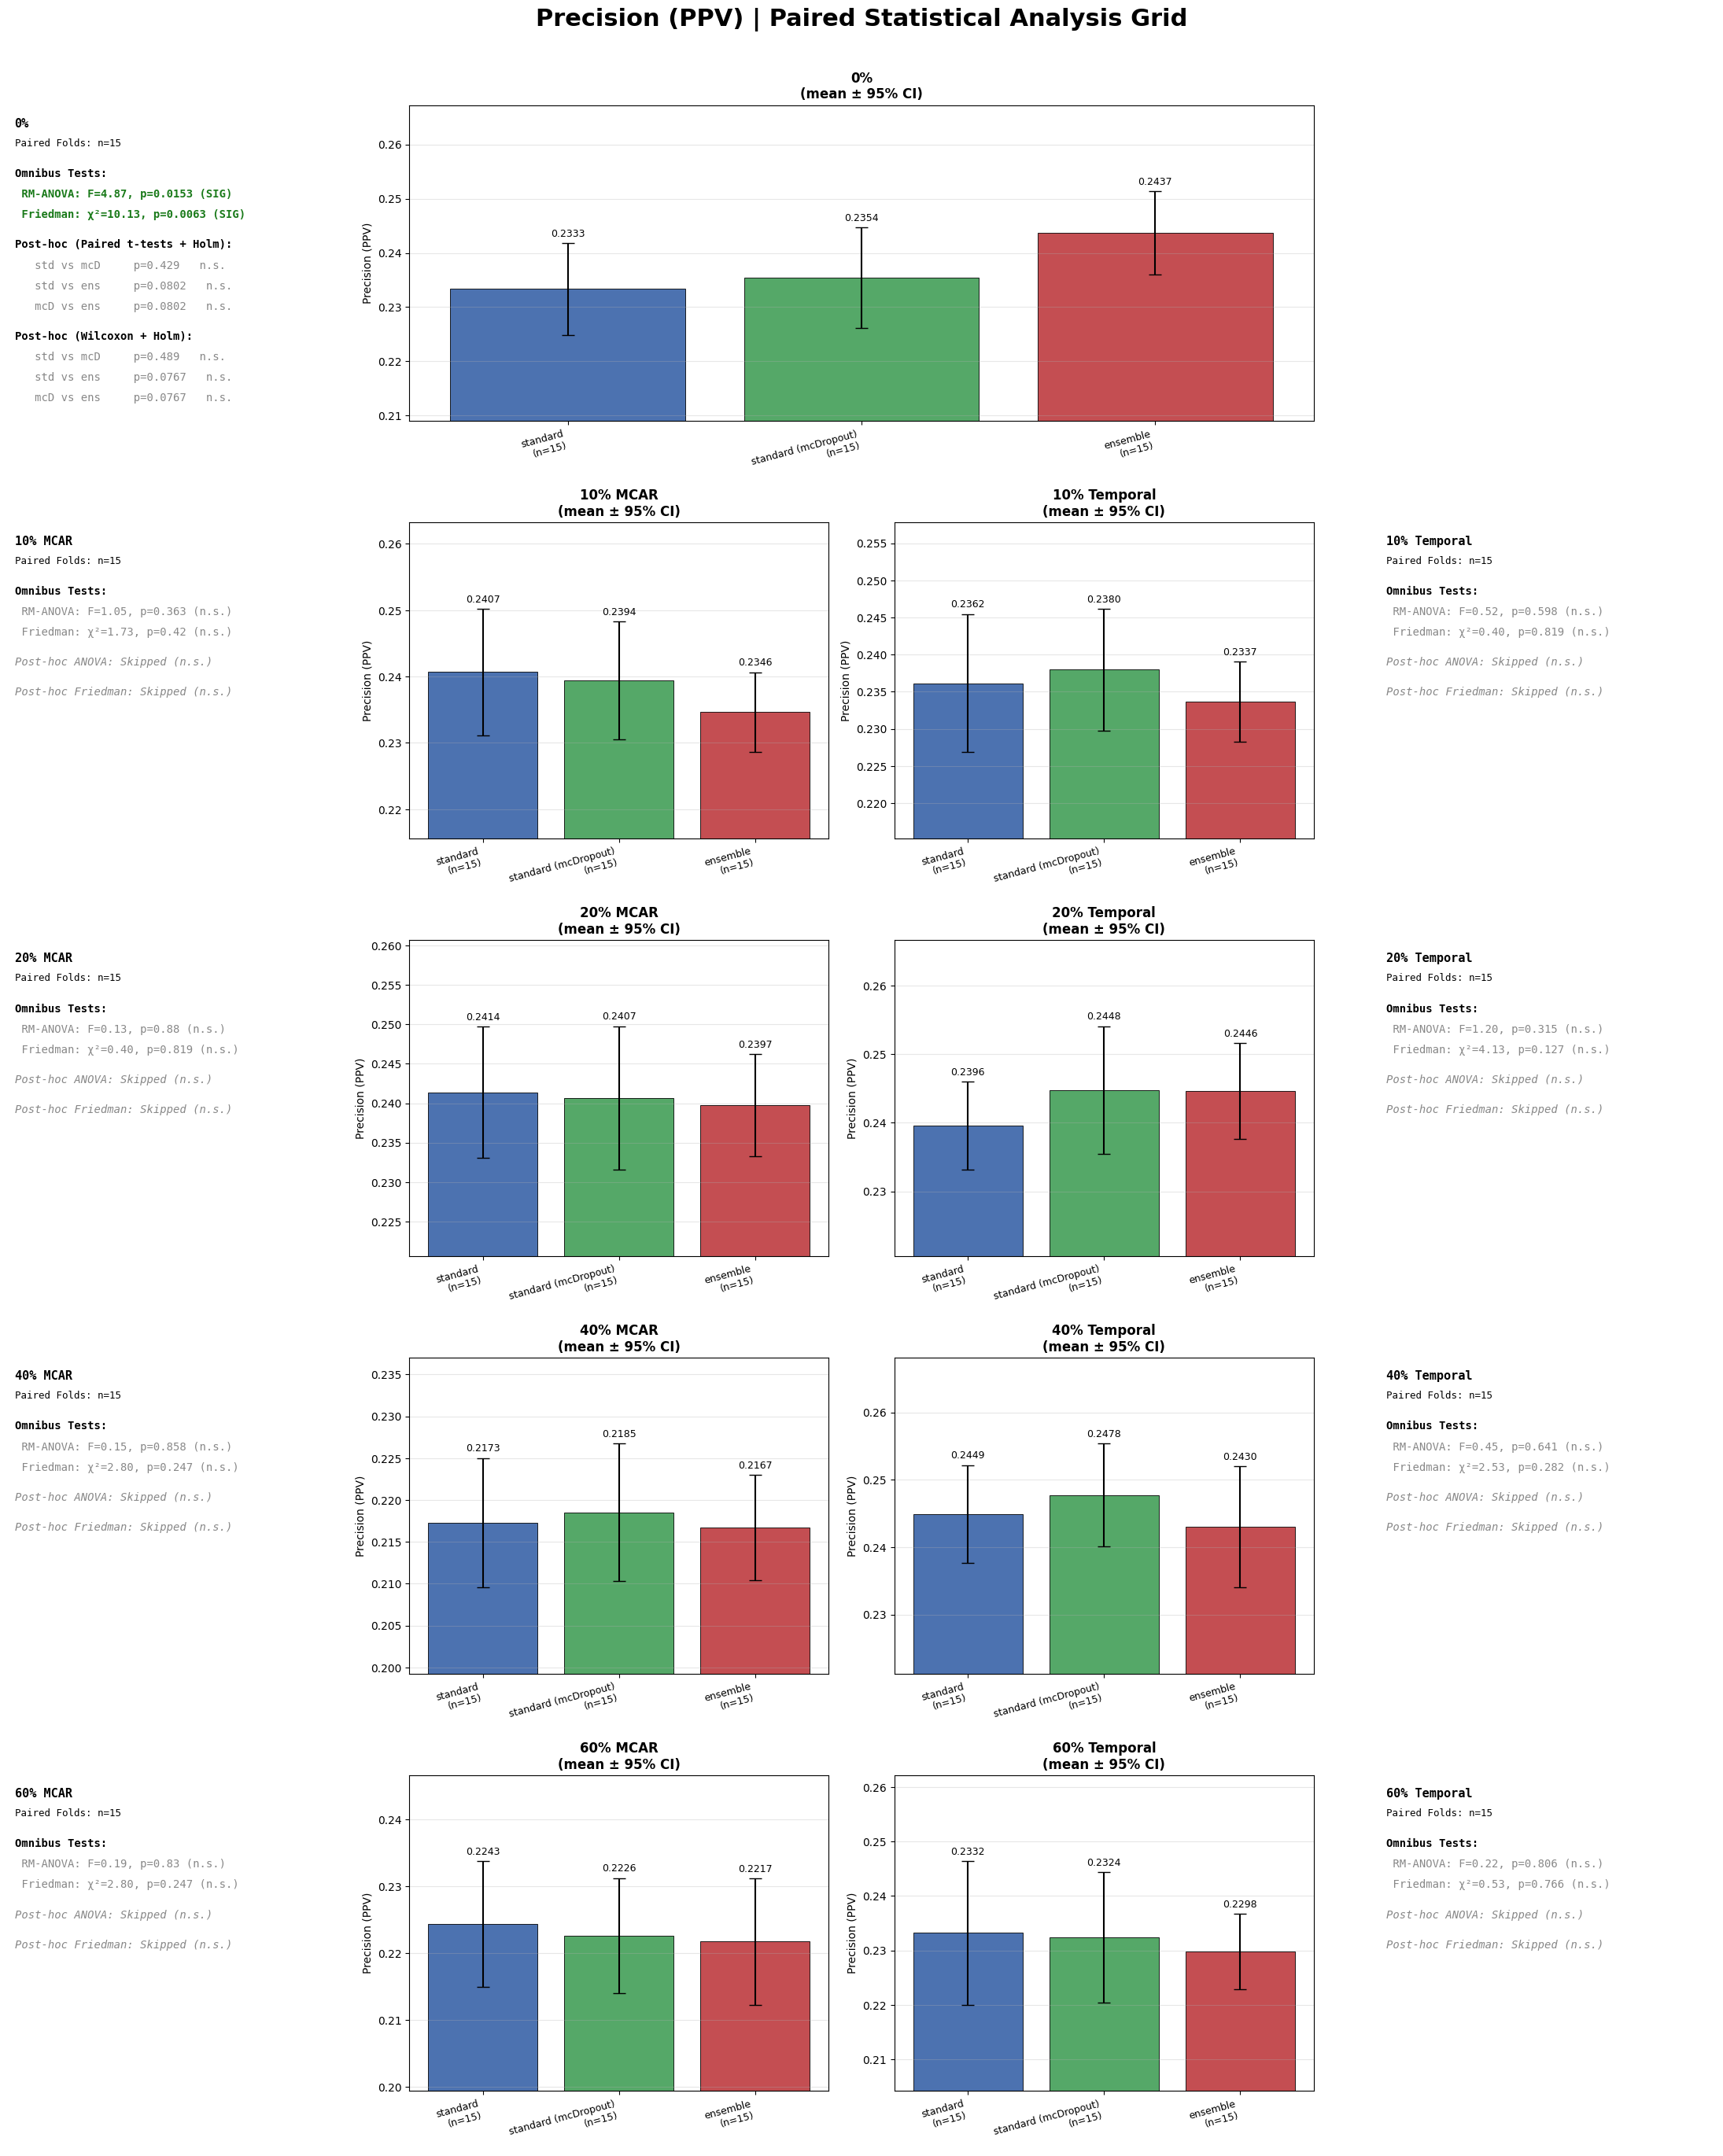

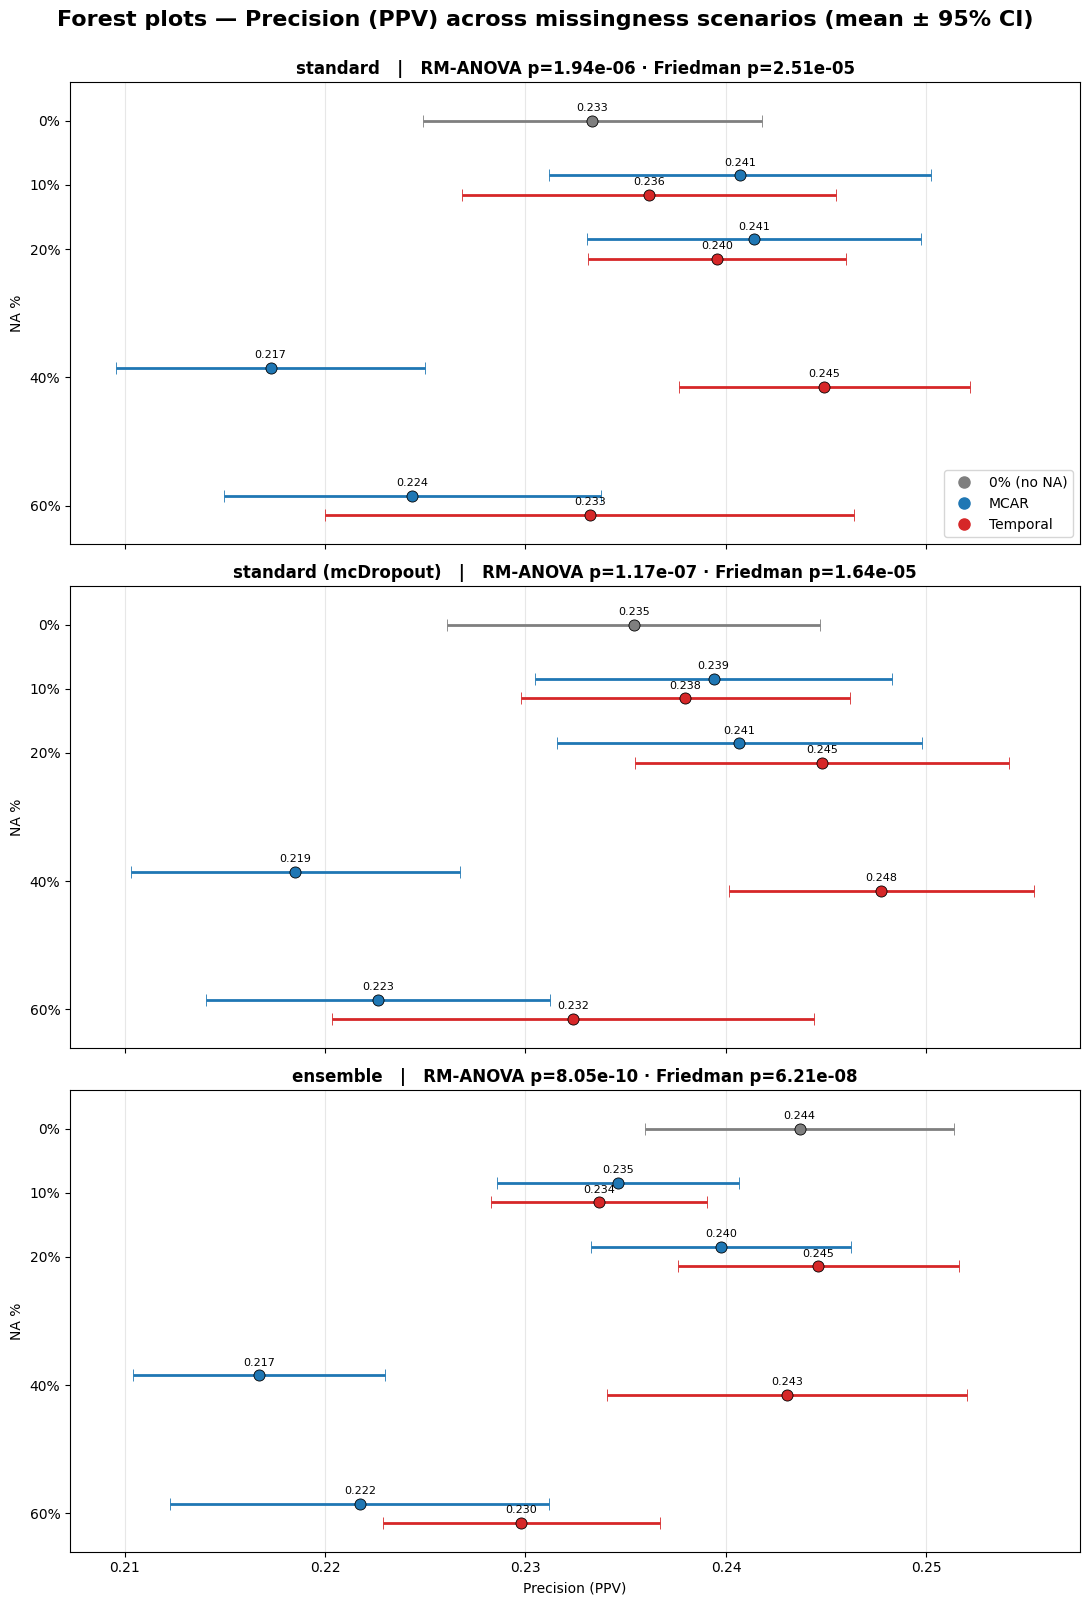

In [106]:
# chage the last argument , for any metric in models_metrics_df.columns (AUC-ROC, Balanced Accuracy )
plot_bar_metrics(models_metrics_df,'Precision (PPV)')
plot_forest(models_metrics_df,'Precision (PPV)')

In [84]:
display(models_metrics_df)

,Model_ds,AUC-ROC,AUC-PR,Applied_Threshold,Balanced_Accuracy,Brier_Score,Brier_Score_Bal,ECE,Calibration_Slope,Accuracy,Recall (Sens),Precision (PPV),Specificity,NPV,True_Positives,False_Positives,True_Negatives,False_Negatives
0,standard1/0%,0.675594,0.258998,0.116794,0.634763,0.118374,0.346412,0.015851,0.135644,0.554632,0.747967,0.211009,0.521558,0.923645,184,688,750,62
1,standard1_mcdropout/0%,0.675068,0.258425,0.117490,0.636501,0.118388,0.346084,0.017648,0.136474,0.557601,0.747967,0.212226,0.525035,0.924113,184,683,755,62
2,standard1/10% MCAR,0.677038,0.259236,0.147662,0.636001,0.118295,0.344877,0.015132,0.136015,0.660333,0.601626,0.237942,0.670376,0.907721,148,474,964,98
3,standard1_mcdropout/10% MCAR,0.677417,0.259462,0.148204,0.635305,0.118290,0.344475,0.015447,0.137130,0.659145,0.601626,0.237179,0.668985,0.907547,148,476,962,98
4,standard1/20% MCAR,0.676264,0.256333,0.132322,0.632066,0.118545,0.345441,0.015526,0.133203,0.610451,0.662602,0.221467,0.601530,0.912447,163,573,865,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,ensemble15/60% MCAR,0.654358,0.228554,0.151688,0.628159,0.121253,0.338540,0.030748,0.133889,0.580760,0.695122,0.213217,0.561196,0.914966,171,631,807,75
401,ensemble15/10% Temporal,0.683382,0.253014,0.159188,0.655014,0.118898,0.337549,0.030631,0.166008,0.649644,0.662602,0.243284,0.647427,0.918146,163,507,931,83
402,ensemble15/20% Temporal,0.682059,0.254940,0.157149,0.651430,0.118646,0.336711,0.027463,0.167688,0.637767,0.670732,0.237752,0.632128,0.918182,165,529,909,81
403,ensemble15/40% Temporal,0.682438,0.272308,0.174459,0.649615,0.118319,0.332018,0.022960,0.168871,0.686461,0.597561,0.255208,0.701669,0.910650,147,429,1009,99


## **PART III** 


### **Analysis of 95% Credible Intervals (95% CrI, 2.5% – 97.5%) Obtained via LSTM MC Dropout Predictions**

In [ ]:
df_pat.info() # All Models Predictions for each instance df

In [86]:
#df_pat['instance'].value_counts()
df_pat.head()

,Dataset,instance,y_true,standard1,standard1_mcdropout,standard2,standard2_mcdropout,standard3,standard3_mcdropout,standard4,...,ensemble6,ensemble7,ensemble8,ensemble9,ensemble10,ensemble11,ensemble12,ensemble13,ensemble14,ensemble15
0,0%,0,0.0,0.16841,"[0.16775162518024445, 0.1687098741531372, 0.16...",0.29549,"[0.2980651259422302, 0.2841811180114746, 0.323...",0.164834,"[0.14500662684440613, 0.16101770102977753, 0.1...",0.239792,...,"[0.21606460213661194, 0.16090866923332214, 0.2...","[0.31820809841156006, 0.20358216762542725, 0.2...","[0.19444873929023743, 0.18933887779712677, 0.2...","[0.19319561123847961, 0.09771271795034409, 0.1...","[0.18393483757972717, 0.14727160334587097, 0.2...","[0.21487164497375488, 0.19412459433078766, 0.2...","[0.2456042766571045, 0.2719951272010803, 0.203...","[0.21060694754123688, 0.22722335159778595, 0.3...","[0.21206122636795044, 0.21437664330005646, 0.2...","[0.22574995458126068, 0.2164710909128189, 0.17..."
1,0%,1,0.0,0.12869,"[0.11716275662183762, 0.12201635539531708, 0.1...",0.166989,"[0.15420454740524292, 0.16143089532852173, 0.1...",0.161656,"[0.18182332813739777, 0.145909383893013, 0.166...",0.211406,...,"[0.18420714139938354, 0.17091740667819977, 0.1...","[0.2203112691640854, 0.19217528402805328, 0.21...","[0.16035443544387817, 0.1628127545118332, 0.23...","[0.18811078369617462, 0.1713707000017166, 0.13...","[0.19782930612564087, 0.19086191058158875, 0.1...","[0.1652400940656662, 0.15609566867351532, 0.22...","[0.15934616327285767, 0.1498180329799652, 0.15...","[0.1802782565355301, 0.1814281940460205, 0.186...","[0.23491695523262024, 0.19724401831626892, 0.2...","[0.1260278820991516, 0.18782871961593628, 0.19..."
2,0%,2,0.0,0.142589,"[0.15113207697868347, 0.1288524866104126, 0.12...",0.193369,"[0.17880947887897491, 0.20436827838420868, 0.2...",0.176856,"[0.16537536680698395, 0.18289341032505035, 0.1...",0.230215,...,"[0.19324186444282532, 0.19042110443115234, 0.2...","[0.2197445183992386, 0.21482957899570465, 0.22...","[0.17826880514621735, 0.1673848181962967, 0.26...","[0.2120170295238495, 0.18788361549377441, 0.15...","[0.22605383396148682, 0.2084505707025528, 0.23...","[0.18152382969856262, 0.17843817174434662, 0.2...","[0.1804836392402649, 0.18087241053581238, 0.18...","[0.1821441501379013, 0.20292304456233978, 0.22...","[0.24838295578956604, 0.23274725675582886, 0.2...","[0.16068729758262634, 0.20459268987178802, 0.2..."
3,0%,3,0.0,0.236587,"[0.24511921405792236, 0.23847152292728424, 0.2...",0.228028,"[0.25579047203063965, 0.21166548132896423, 0.2...",0.159905,"[0.18689371645450592, 0.15812911093235016, 0.1...",0.212226,...,"[0.23679830133914948, 0.20069974660873413, 0.2...","[0.30346107482910156, 0.19156385958194733, 0.2...","[0.21224361658096313, 0.1980341523885727, 0.28...","[0.205808624625206, 0.16698963940143585, 0.214...","[0.20257523655891418, 0.22628432512283325, 0.2...","[0.2208954244852066, 0.20222346484661102, 0.25...","[0.2608864903450012, 0.30251723527908325, 0.24...","[0.2450193464756012, 0.23582811653614044, 0.22...","[0.22316798567771912, 0.2698304355144501, 0.24...","[0.21149803698062897, 0.20933400094509125, 0.1..."
4,0%,4,0.0,0.077417,"[0.08935897797346115, 0.08348529040813446, 0.0...",0.104903,"[0.12220405042171478, 0.12218855321407318, 0.0...",0.086394,"[0.08495838940143585, 0.07797965407371521, 0.0...",0.108855,...,"[0.09564410150051117, 0.05179823562502861, 0.0...","[0.08350742608308792, 0.10805408656597137, 0.0...","[0.08293803781270981, 0.08358456939458847, 0.1...","[0.11903247237205505, 0.08711931109428406, 0.1...","[0.12181679904460907, 0.09636886417865753, 0.0...","[0.07740553468465805, 0.08459412306547165, 0.1...","[0.09387471526861191, 0.08075712621212006, 0.0...","[0.10972875356674194, 0.09264632314443588, 0.1...","[0.11670807003974915, 0.09414190798997879, 0.1...","[0.0935170128941536, 0.08988653868436813, 0.11..."


## **LSTM Prediction Categorization for Descriptive Analysis and Correlation Studies with 95% MC-Dropout Credible Intervals (95% CrI)**

To facilitate a more contextualized analysis, a categorization framework was developed based on the models' probabilistic predictions. 

The predictions were classified into four distinct groups: *confident correct*, *confident error*, *borderline correct*, and *borderline error*. A decision threshold of 14.5% was adopted to determine correct and incorrect classifications. A margin of approximately 20% around this threshold was applied, leading to the consideration of predictions between 11.5% and 17.5% as *borderline*, while predictions outside this range were classified as *confident*.

Prediction values from the models yielding median AUC-PR (and matching median AUC-ROC) values across the K-fold cross-validation were selected, since these metrics are threshold-independent and the median performance provides a more representative measure of the algorithm mitigating selection bias across validation folds [1]. Furthermore, the use of AUC-PR is highly recommended for evaluating mortality prediction in intensive care settings due to severe class imbalance, following established clinical machine learning benchmarks [2]."

---
### **References**
- [1] *[1] T. Hastie, R. Tibshirani, and J. Friedman, The Elements of Statistical Learning: Data Mining, Inference, and Prediction, 2nd ed. New York, NY, USA: Springer Science & Business Media, 2009, ch. 7, pp. 241–249*
- [2] Harutyunyan, H., Khachatrian, H., Kale, D.C. et al. Multitask learning and benchmarking with clinical time series data. Sci Data 6, 96 (2019). https://doi.org/10.1038/s41597-019-0103-9


In [87]:



def categorize_errors(y_true, y_prob, threshold, margin=0.1):
    """
    Bucket each instance by (a) whether the thresholded prediction is correct
    and (b) whether the predicted probability lies within 'margin' of the
    decision threshold. Returns an object array aligned to the input order.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    pred = (y_prob >= threshold).astype(int)
    is_error = (pred != y_true)
    is_borderline = np.abs(y_prob - threshold) <= margin

    categories = np.empty(len(y_true), dtype=object)
    categories[is_error  & ~is_borderline] = 'confident_error'
    categories[is_error  &  is_borderline] = 'borderline_error'
    categories[~is_error &  is_borderline] = 'borderline_correct'
    categories[~is_error & ~is_borderline] = 'confident_correct'
    return categories


def build_df_pat_met(df_pat, threshold=0.145, margin=0.03,
                     std_col='standard2', mc_col='standard2_mcdropout', ens_col='ensemble9'):
    """
    Build a patient-level metrics table (df_pat_met) from df_pat. For every
    instance it adds:
      - point predictions for the three chosen predictors:
          * standard fold 2          (scalar in df_pat[std_col])
          * MC-dropout fold 2 mean   (mean of the sample list in df_pat[mc_col])
          * ensemble fold 9 mean     (mean of the member list in df_pat[ens_col])
      - an error/confidence category for each predictor (threshold=0.145, margin=0.03)
      - CrI95_mcdropout2: width of the 95% MC-dropout credible interval, fold 2
                         (P97.5 - P2.5 over the sample list)
    """
    df = df_pat.reset_index(drop=True)
    y_true = df['y_true'].to_numpy()

    # point predictions
    p_std = df[std_col].to_numpy(dtype=float)                          # standard fold 2 (scalar)
    p_mc  = df[mc_col].apply(lambda s: float(np.mean(s))).to_numpy()   # MC-dropout fold 2 (mean)
    p_ens = df[ens_col].apply(lambda s: float(np.mean(s))).to_numpy()  # ensemble fold 9 (mean)

    # 95% credible-interval width of the MC-dropout samples (fold 2)
    def cri95_width(samples):
        s = np.asarray(samples, dtype=float)
        return float(np.percentile(s, 97.5) - np.percentile(s, 2.5))
    ci_mc = df[mc_col].apply(cri95_width).to_numpy()

    df_pat_met = pd.DataFrame({
        'Dataset': df['Dataset'].to_numpy(),
        'instance': df['instance'].to_numpy(),
        'y_true': y_true,
        'pred_standard2': p_std,
        'pred_mcdropout2_mean': p_mc,
        'pred_ensemble9_mean': p_ens,
        'cat_standard2':  categorize_errors(y_true, p_std, threshold, margin),
        'cat_mcdropout2': categorize_errors(y_true, p_mc,  threshold, margin),
        'cat_ensemble9':  categorize_errors(y_true, p_ens, threshold, margin),
        'CrI95_mcdropout2': ci_mc,
    })
    return df_pat_met




In [88]:
df_pat_met = build_df_pat_met(df_pat, threshold=0.145, margin=0.03)

In [89]:
df_pat_met['Dataset'].value_counts()

Dataset
0%              1684
10% MCAR        1684
10% Temporal    1684
20% MCAR        1684
20% Temporal    1684
40% MCAR        1684
40% Temporal    1684
60% MCAR        1684
60% Temporal    1684
Name: count, dtype: int64

In [90]:
df_pat_met.info()

<class 'pandas.DataFrame'>
RangeIndex: 15156 entries, 0 to 15155
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dataset               15156 non-null  str    
 1   instance              15156 non-null  int64  
 2   y_true                15156 non-null  float32
 3   pred_standard2        15156 non-null  float64
 4   pred_mcdropout2_mean  15156 non-null  float64
 5   pred_ensemble9_mean   15156 non-null  float64
 6   cat_standard2         15156 non-null  str    
 7   cat_mcdropout2        15156 non-null  str    
 8   cat_ensemble9         15156 non-null  str    
 9   CrI95_mcdropout2      15156 non-null  float64
dtypes: float32(1), float64(4), int64(1), str(4)
memory usage: 1.9 MB


In [91]:
cols = ['cat_standard2', 'cat_mcdropout2', 'cat_ensemble9']
for col in cols:
    print(df_pat_met[col].value_counts())
#Similar number of each 

cat_standard2
confident_correct     4449
confident_error       4109
borderline_correct    3861
borderline_error      2737
Name: count, dtype: int64
cat_mcdropout2
confident_correct     4368
confident_error       4141
borderline_correct    3824
borderline_error      2823
Name: count, dtype: int64
cat_ensemble9
confident_correct     4685
confident_error       4518
borderline_correct    3169
borderline_error      2784
Name: count, dtype: int64


In [92]:


# 1. Define the exact target instances (names) and the desired columns
target_names = ["confident_correct", "confident_error", "borderline_correct", "borderline_error"]
target_columns = ['cat_standard2', 'cat_mcdropout2', 'cat_ensemble9']

# 2. "Melt" the dataframe to reshape category columns into rows for easier counting
df_melt = df_pat_met.melt(
    id_vars=['Dataset'], 
    value_vars=target_columns, 
    var_name='model_column', 
    value_name='instance_name'
)

# 3. Clean up any trailing/leading whitespaces from the category strings
df_melt['instance_name'] = df_melt['instance_name'].str.strip()

# 4. Group by instance, dataset, and model column, count them, and pivot the models back to columns
df_counts = (
    df_melt.groupby(['instance_name', 'Dataset', 'model_column'])
    .size()
    .unstack(level='model_column', fill_value=0)
)

# 5. Create a complete MultiIndex to guarantee all name/dataset combinations exist
all_datasets = df_pat_met['Dataset'].unique()
complete_index = pd.MultiIndex.from_product(
    [target_names, all_datasets], 
    names=['instance_name', 'Dataset']
)

# 6. Reindex rows and columns to enforce the exact structure and fill missing entries with 0
df_view = df_counts.reindex(complete_index, fill_value=0).reindex(columns=target_columns)

# Display the final structured DataFrame view


In [93]:
df_view # tabela de de numero de predições categoricas por modelo - colocar em apencies

model_column                     cat_standard2  cat_mcdropout2  cat_ensemble9
instance_name      Dataset                                                   
confident_correct  0%                      515             510            539
                   10% MCAR                502             491            530
                   10% Temporal            493             482            525
                   20% MCAR                510             503            545
                   20% Temporal            524             507            558
                   40% MCAR                480             476            518
                   40% Temporal            469             463            493
                   60% MCAR                482             473            478
                   60% Temporal            474             463            499
confident_error    0%                      424             428            473
                   10% MCAR                427             432            481
                   10% Temporal            435             438            470
                   20% MCAR                434             441            460
                   20% Temporal            444             448            475
                   40% MCAR                456             459            503
                   40% Temporal            478             483            516
                   60% MCAR                488             486            541
                   60% Temporal            523             526            599
borderline_correct 0%                      441             431            376
                   10% MCAR                450             446            377
                   10% Temporal            445             424            374
                   20% MCAR                435             431            345
                   20% Temporal            416             429            332
                   40% MCAR                430             432            362
                   40% Temporal            441             433            357
                   60% MCAR                414             412            354
                   60% Temporal            389             386            292
borderline_error   0%                      304             315            296
                   10% MCAR                305             315            296
                   10% Temporal            311             340            315
                   20% MCAR                305             309            334
                   20% Temporal            300             300            319
                   40% MCAR                318             317            301
                   40% Temporal            296             305            318
                   60% MCAR                300             313            311
                   60% Temporal            298             309            294

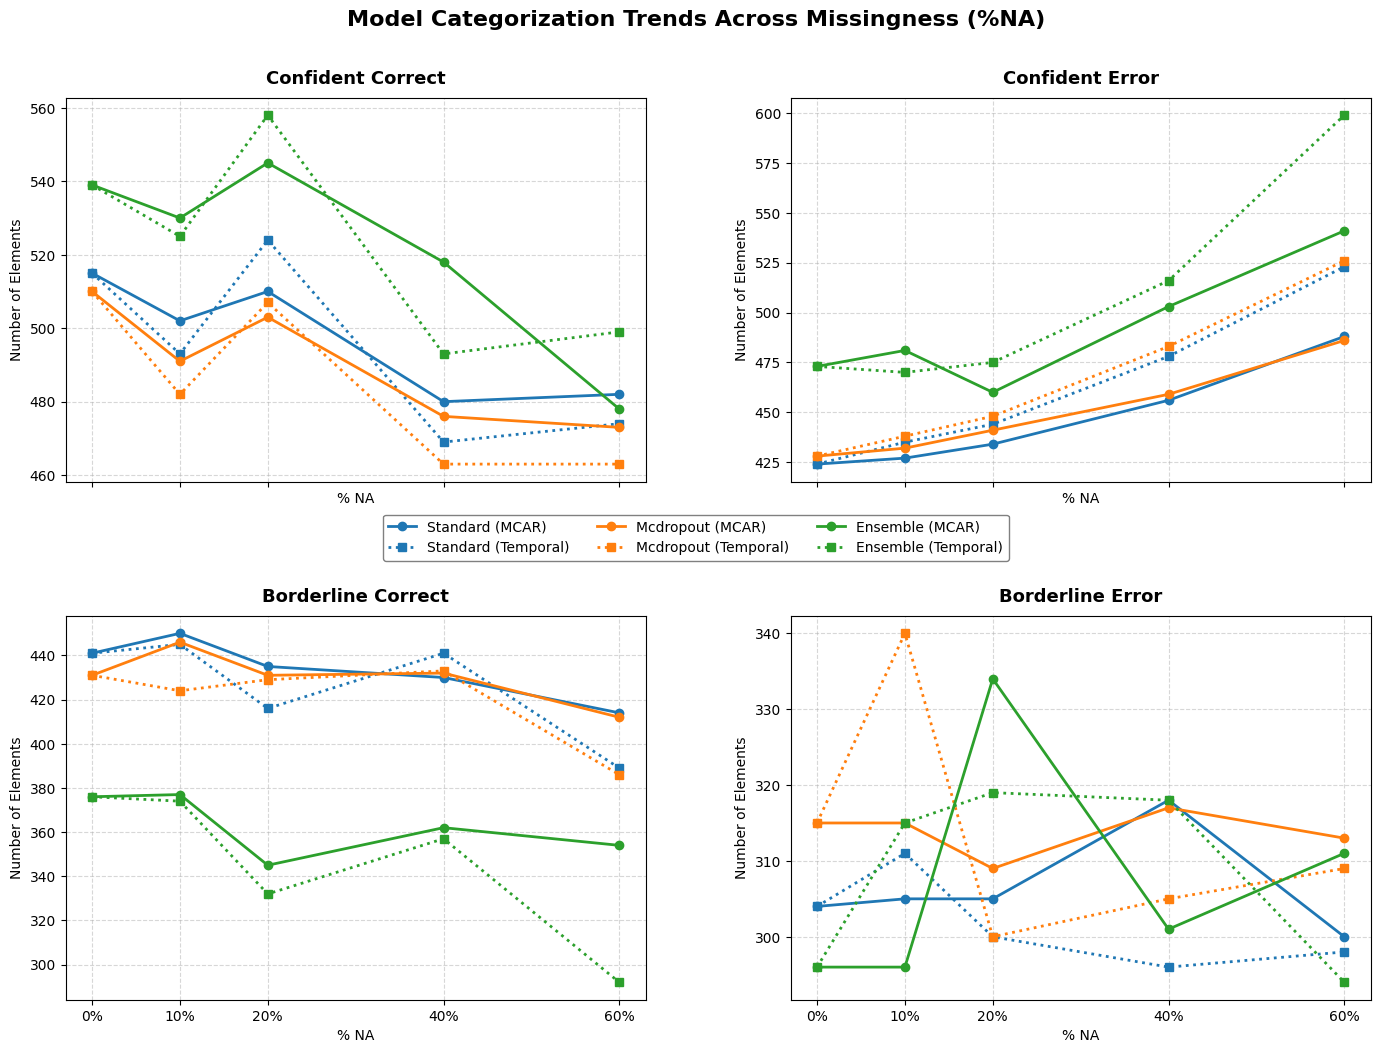

In [94]:
# Plotting Chart of Lines

# 1. Define target structures matching your df_view
target_names = ["confident_correct", "confident_error", "borderline_correct", "borderline_error"]

# Mapping dictionary to change the technical column names to your display names
name_mapping = {
    'cat_standard2': 'Standard',
    'cat_mcdropout2': 'Mcdropout',
    'cat_ensemble9': 'Ensemble'
}

# Updated target columns list matching the new names
target_columns = ['Standard', 'Mcdropout', 'Ensemble']

# X-axis numerical positions and their respective string mappings in df_view
x_vals = [0, 10, 20, 40, 60]
mcar_idx = ['0%', '10% MCAR', '20% MCAR', '40% MCAR', '60% MCAR']
temp_idx = ['0%', '10% Temporal', '20% Temporal', '40% Temporal', '60% Temporal']

# Color mapping updated to use the new names as keys
colors = {
    'Standard': '#1f77b4',   # Blue
    'Mcdropout': '#ff7f0e',  # Orange
    'Ensemble': '#2ca02c'    # Green
}

# Rename the columns in a temporary DataFrame copy dedicated for plotting
df_plot = df_view.rename(columns=name_mapping)

# 2. Setup a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
fig.suptitle('Model Categorization Trends Across Missingness (%NA)', fontsize=16, fontweight='bold', y=0.98)

# 3. Iterate through each target name to draw its line chart
for i, name in enumerate(target_names):
    # Determine the correct subplot positioning axis
    ax = axes[i // 2, i % 2]
    
    # Extract the subset data from the renamed plot DataFrame
    df_sub = df_plot.loc[name]
    
    # Reindex data to match the exact order of x_vals sequence
    df_mcar = df_sub.reindex(mcar_idx)
    df_temp = df_sub.reindex(temp_idx)
    
    # Plot lines for each renamed model column
    for col in target_columns:
        # MCAR Line: Solid (-), circle marker
        ax.plot(x_vals, df_mcar[col].values, linestyle='-', marker='o', 
                color=colors[col], linewidth=2, label=f'{col} (MCAR)')
        
        # Temporal Line: Dotted (:), square marker
        ax.plot(x_vals, df_temp[col].values, linestyle=':', marker='s', 
                color=colors[col], linewidth=2, label=f'{col} (Temporal)')
    
    # Subplot configurations
    ax.set_title(name.replace('_', ' ').title(), fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Number of Elements', fontsize=10)
    ax.set_xlabel('% NA', fontsize=10)
    ax.set_xticks(x_vals)
    ax.set_xticklabels([f'{x}%' for x in x_vals])
    ax.grid(True, linestyle='--', alpha=0.5)

# 4. Extract handles and labels from the last axis to build the global legend
handles, labels = ax.get_legend_handles_labels()

# 5. Position a single global legend at the exact center of the figure
# The labels will now neatly show "Standard (MCAR)", "Mcdropout (Temporal)", etc.
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.5), 
           ncol=3, fontsize=10, frameon=True, framealpha=1.0, 
           facecolor='white', edgecolor='gray')

# 6. Adjust subplot spacing to push the charts apart and leave room for the center legend
plt.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.08, hspace=0.35, wspace=0.25)

plt.show()

### Lines Graprs: Classifications distribution by model across varying levels of data missingness (% NA).
 The 2×2 grid displays absolute instance counts for four distinct error-agreement categories: Confident Correct (top-left), Confident Error (top-right), Borderline Correct (bottom-left), and Borderline Error (bottom-right). Line colors denote the evaluated models: Standard (Blue), Mcdropout (Orange), and Ensemble (Green). Line styles and markers differentiate the missingness mechanisms: Solid lines with circles indicate MCAR, while dotted lines with squares indicate Temporal missingness. All configurations originate from a unified baseline at 0% missingness to illustrate behavioral divergence as data degrades.

In [ ]:



def _holm(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for r, idx in enumerate(order):
        run = max(run, (m-r)*p[idx]); adj[idx] = min(run, 1.0)
    return adj


def compare_cri95_across_groups(df_pat_met, value_col='CrI95_mcdropout2',
                               cat_cols=('cat_standard2', 'cat_mcdropout2', 'cat_ensemble9'),
                               correct='confident_correct', error='confident_error',
                               verbose=True):
    """
    Split rows of df_pat_met into 3 INDEPENDENT groups by category agreement:
        'all_confident_correct' : all cat_cols == correct
        'all_confident_error'   : all cat_cols == error
        'other'                 : everything else
    Tests whether the mean of `value_col` (95% MC-dropout CI width) differs across
    groups with one-way ANOVA (parametric) and Kruskal-Wallis (non-parametric; the
    correct counterpart to Friedman for INDEPENDENT, unequal-size groups). If either
    omnibus test is significant, runs Holm-corrected Mann-Whitney U pairwise post-hoc.

    Returns (res, metrics):
        res     -> dict: omnibus test results, pairwise post-hoc, per-row group labels
        metrics -> DataFrame: all descriptive metrics per group
    """
    cats = df_pat_met[list(cat_cols)]
    all_correct = (cats == correct).all(axis=1).to_numpy()
    all_error   = (cats == error).all(axis=1).to_numpy()
    group = np.where(all_correct, 'all_confident_correct',
            np.where(all_error,   'all_confident_error', 'other'))
    df = df_pat_met.copy(); df['group'] = group

    order = ['all_confident_correct', 'all_confident_error', 'other']
    samples = {g: df.loc[df['group'] == g, value_col].dropna().to_numpy() for g in order}

    # ---- METRICS: descriptive stats per group ----
    rows = []
    for g in order:
        v = samples[g]; n = len(v)
        ci = stats.t.ppf(0.975, n-1)*(v.std(ddof=1)/np.sqrt(n)) if n > 1 else np.nan
        rows.append({'group': g, 'n': n,
                     'mean': v.mean() if n else np.nan,
                     'median': np.median(v) if n else np.nan,
                     'std': v.std(ddof=1) if n > 1 else np.nan,
                     'min': v.min() if n else np.nan,
                     'q25': np.percentile(v, 25) if n else np.nan,
                     'q75': np.percentile(v, 75) if n else np.nan,
                     'max': v.max() if n else np.nan,
                     'ci95_halfwidth': ci})
    metrics = pd.DataFrame(rows)

    # ---- RES: omnibus tests (ANOVA + Kruskal-Wallis) + pairwise if significant ----
    valid = [samples[g] for g in order if len(samples[g]) >= 2]
    omnibus, posthoc = {}, []
    if len(valid) >= 2:
        F, p_av = stats.f_oneway(*valid)
        H, p_kw = stats.kruskal(*valid)
        omnibus = {'anova_F': F, 'anova_p': p_av, 'kruskal_H': H, 'kruskal_p': p_kw}
        if (p_av < 0.05) or (p_kw < 0.05):                 # post-hoc only if omnibus fires
            present = [g for g in order if len(samples[g]) >= 2]
            pairs = list(combinations(present, 2))
            raw = []
            for a, b in pairs:
                try: _, pw = stats.mannwhitneyu(samples[a], samples[b], alternative='two-sided')
                except ValueError: pw = 1.0
                raw.append(pw)
            for (a, b), padj, praw in zip(pairs, _holm(raw), raw):
                posthoc.append({'pair': f'{a} vs {b}', 'p_raw': praw,
                                'p_holm': padj, 'significant': bool(padj < 0.05)})

    res = {'omnibus': omnibus, 'posthoc': posthoc, 'group': group}

    if verbose:
        print('METRICS (CI95 width per group):'); print(metrics.to_string(index=False))
        if omnibus:
            print(f"\nOne-way ANOVA  : F={omnibus['anova_F']:.3f}, p={omnibus['anova_p']:.3e}"
                  + ('  SIG' if omnibus['anova_p'] < 0.05 else '  n.s.'))
            print(f"Kruskal-Wallis : H={omnibus['kruskal_H']:.3f}, p={omnibus['kruskal_p']:.3e}"
                  + ('  SIG' if omnibus['kruskal_p'] < 0.05 else '  n.s.'))
            if posthoc:
                print('\nPost-hoc (Mann-Whitney U, Holm):')
                for r in posthoc:
                    print(f"   {r['pair']:<48} p={r['p_holm']:.3e}  {'SIG' if r['significant'] else 'n.s.'}")
            else:
                print('\nPost-hoc: omnibus n.s. -> skipped')
        else:
            print('\nNot enough groups with >=2 samples to run tests.')

    return res, metrics




In [98]:

# per-Dataset comparison: res dict keyed by Dataset, metrics accumulated
res_by_dataset = {}
metrics_all = pd.DataFrame()

for value in df_pat_met['Dataset'].unique():
    subset = df_pat_met[df_pat_met['Dataset'] == value]
    res, metrics = compare_cri95_across_groups(subset, verbose=False)

    res_by_dataset[value] = res                 # tests for this Dataset

    chunk = metrics.copy()
    chunk.insert(0, 'Dataset', value)           # tag the metrics with the Dataset value
    metrics_all = pd.concat([metrics_all, chunk], ignore_index=True)

metrics_all = metrics_all.set_index('Dataset')  # each metrics row identified by its Dataset value

In [99]:
def _fmt_p(p):
    """Journal-style p formatting: 'p < 0.001' below that threshold, else the value."""
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def print_res_by_dataset(res_by_dataset):
    """
    Print results per Dataset key: for each key, either 'No Statistical significant'
    (no post-hoc pair survived), or the significant pairs with their (Holm) p-value.
    """
    for key, res in res_by_dataset.items():
        print(f"=== {key} ===")
        sig_pairs = [r for r in res.get('posthoc', []) if r['significant']]
        if not sig_pairs:
            print("   No Statistical significant")
        else:
            for r in sig_pairs:
                print(f"   {r['pair']}: {_fmt_p(r['p_holm'])}")


# usage
print_res_by_dataset(res_by_dataset)

=== 0% ===
   all_confident_correct vs all_confident_error: p < 0.001
   all_confident_correct vs other: p < 0.001
   all_confident_error vs other: p < 0.001
=== 10% MCAR ===
   all_confident_correct vs all_confident_error: p < 0.001
   all_confident_correct vs other: p < 0.001
   all_confident_error vs other: p < 0.001
=== 10% Temporal ===
   all_confident_correct vs all_confident_error: p < 0.001
   all_confident_correct vs other: p < 0.001
   all_confident_error vs other: p < 0.001
=== 20% MCAR ===
   all_confident_correct vs all_confident_error: p < 0.001
   all_confident_correct vs other: p < 0.001
   all_confident_error vs other: p < 0.001
=== 20% Temporal ===
   all_confident_correct vs all_confident_error: p < 0.001
   all_confident_correct vs other: p < 0.001
   all_confident_error vs other: p < 0.001
=== 40% MCAR ===
   all_confident_correct vs all_confident_error: p < 0.001
   all_confident_correct vs other: p < 0.001
   all_confident_error vs other: p = 0.003
=== 40% Tempor

In [100]:
metrics_all.head()

,group,n,mean,median,std,min,q25,q75,max,ci95_halfwidth
Dataset,,,,,,,,,,
0%,all_confident_correct,438,0.051599,0.050296,0.009885,0.026560,0.045310,0.056855,0.082001,0.000928
0%,all_confident_error,362,0.056330,0.056315,0.010835,0.023513,0.049447,0.063983,0.088411,0.001120
0%,other,884,0.059225,0.058773,0.008143,0.034085,0.053659,0.064393,0.090017,0.000538
10% MCAR,all_confident_correct,417,0.052134,0.051211,0.009559,0.028051,0.046128,0.057589,0.089493,0.000920
10% MCAR,all_confident_error,355,0.055090,0.055496,0.011322,0.026491,0.047791,0.061906,0.087648,0.001182


In [101]:

def plot_forest2(metrics_all, value_label='CrI95% Mean (MC dropout)'):
    """
    Univariate forest plot of the per-group mean CI95_mcdropout2 stored in
    metrics_all (3 rows per dataset: the agreement groups). y = NA% (0% on top,
    60% nearest the x-axis). Each dataset (NA% + missingness kind) draws its 3
    groups as 3 adjacent lines: color encodes the group, marker encodes the kind
    (0% / MCAR / Temporal). x = mean CrI95 width, error bar = its 95% CI half-width.
    """
    GROUP_ORDER = ['all_confident_correct', 'all_confident_error', 'other']
    GROUP_COLOR = {'all_confident_correct': '#2ca02c',
                   'all_confident_error':   '#d62728',
                   'other':                 '#7f7f7f'}
    
    # Mapeamento dos novos nomes para a legenda
    GROUP_LABELS = {'all_confident_correct': 'Conf. Correct',
                    'all_confident_error':   'Conf. Error',
                    'other':                 'Gray Zone'}
    
    KIND_MARKER = {'0%': 'D', 'MCAR': 'o', 'Temporal': 's'}
    KIND_OFF    = {'0%': 0.0, 'MCAR': -3.5, 'Temporal': +3.5}     # separate same-NA% datasets
    GROUP_OFF   = {'all_confident_correct': -0.9,                 # separate the 3 groups within a dataset
                   'all_confident_error':    0.0,
                   'other':                 +0.9}

    # Map the raw NA% values to your custom non-linear Y-axis ticks
    NA_Y_MAPPING = {0: 0, 10: 10, 20: 27, 40: 45, 60: 62}

    df = metrics_all.copy()
    if 'Dataset' not in df.columns:          # accept Dataset as index or column
        df = df.reset_index()

    fig, ax = plt.subplots(figsize=(11, 9))
    fig.suptitle(f'Forest plot —  by error-agreement group across missingness',
                 fontsize=14, fontweight='bold', y=0.98)

    for _, row in df.iterrows():
        grp = row['group']
        if grp not in GROUP_OFF:
            continue
        na, kind = _scenario_meta(row['Dataset'])
        
        # Convert na to integer to safely look up its baseline Y position
        try:
            na_val = int(float(na))
            base_y = NA_Y_MAPPING.get(na_val, na_val)
        except (ValueError, TypeError):
            base_y = na # Fallback if na isn't numeric
            
        # Calculate final Y position using the non-linear baseline coordinate
        y = base_y + KIND_OFF[kind] + GROUP_OFF[grp]
        
        m, e = row['mean'], row['ci95_halfwidth']
        if pd.isna(m):
            continue
        ax.errorbar(m, y, xerr=(0 if pd.isna(e) else e), fmt=KIND_MARKER[kind],
                    color=GROUP_COLOR[grp], ecolor=GROUP_COLOR[grp], elinewidth=2,
                    capsize=4, markersize=8, markeredgecolor='black', markeredgewidth=0.6)
        ax.annotate(f'{m:.3f}', (m, y), fontsize=7.5, xytext=(0, 6),
                    textcoords='offset points', ha='center')

    # Apply your custom non-linear Y-axis scaling
    ax.set_yticks([0, 10, 27, 45, 62])
    ax.set_yticklabels(['0%', '10%', '20%', '40%', '60%'])
    ax.set_ylim(-8, 70)
    ax.invert_yaxis()                       # 0% on top, 60% near x-axis
    
    ax.set_ylabel('NA %')
    ax.set_xlabel(value_label)
    ax.grid(axis='x', alpha=0.3)

    # two legends outside the plot area: group (color) and kind (marker)
    # Aqui usamos o GROUP_LABELS para atualizar o texto visível na legenda
    group_handles = [mlines.Line2D([], [], color=GROUP_COLOR[g], marker='o', ls='', 
                                   markersize=8, label=GROUP_LABELS[g])
                     for g in GROUP_ORDER]
                     
    kind_handles = [mlines.Line2D([], [], color='black', marker=KIND_MARKER[k], ls='', markersize=8, label=k)
                    for k in ['0%', 'MCAR', 'Temporal']]
                    
    leg1 = ax.legend(handles=group_handles, title='Group', loc='upper left',
                     bbox_to_anchor=(1.01, 1.0), frameon=True)
    ax.add_artist(leg1)
    ax.legend(handles=kind_handles, title='Missingness', loc='upper left',
              bbox_to_anchor=(1.01, 0.62), frameon=True)

    plt.tight_layout()
    plt.show()

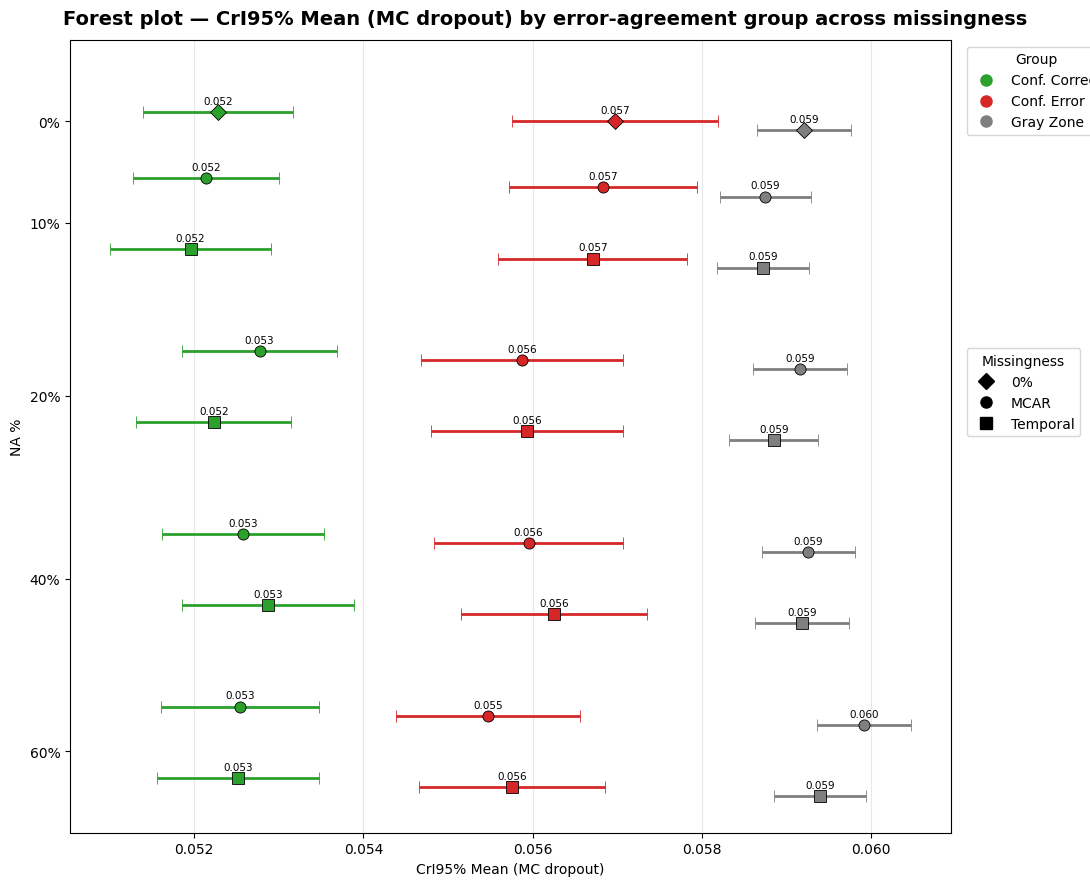

In [ ]:
plot_forest2(metrics_all)